In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
from scipy.stats import kruskal

In [3]:
col_map = {"Water": "PC", "CFA": "TCFA", "FLA": "TFLA", "HCA": "THCA", "LPA": "TLPA", "L4": "TL4", "M4": "TM4"}

# Deinococcus gobienses I-0 12 wells plate 24th hr OD600

Deinococcus gobienses I-0 strain was culture in 12 wells plate treated with lignin precursors caffeic acid (CFA), p-coumaric acid (HCA), ferulic acid (FLA), L-phenylalanine (LPA), coctail of the lower concentration of all four lignin precursors found in rice plant (L4), and coctail of the medium concentration of all four lignin precursors found in rice plant (M4). The OD was measured at 0 and 24th hr.

In [5]:
dg_24 = pd.read_excel('dg_24th_hr_raw_data.xlsx')
dg_24

,Samples,Water,CFA,FLA,HCA,LPA,L4,M4
0,C1,0.042,0.060,0.082,0.017,0.036,0.086,0.052
1,C2,0.012,0.032,0.034,0.039,0.009,0.081,0.047
2,C3,0.035,0.038,0.053,0.010,0.038,0.076,0.042
3,DG1,2.500,0.445,0.459,0.778,0.830,0.375,0.245
4,DG2,1.025,0.354,0.460,0.732,0.886,0.346,0.193
5,DG3,0.844,0.491,0.450,0.766,0.939,0.355,0.206


In [12]:
dg_24 = dg_24.rename(columns=col_map)

In [14]:
dg_24

,Samples,PC,TCFA,TFLA,THCA,TLPA,TL4,TM4
0,C1,0.042,0.060,0.082,0.017,0.036,0.086,0.052
1,C2,0.012,0.032,0.034,0.039,0.009,0.081,0.047
2,C3,0.035,0.038,0.053,0.010,0.038,0.076,0.042
3,DG1,2.500,0.445,0.459,0.778,0.830,0.375,0.245
4,DG2,1.025,0.354,0.460,0.732,0.886,0.346,0.193
5,DG3,0.844,0.491,0.450,0.766,0.939,0.355,0.206


In [16]:
dg_24_clean = pd.DataFrame()

# Process columns 1 to 7 (Python index 1 to 7 is df.columns[1:8])
for col in dg_24.columns[1:8]:
    # Calculate the average of rows 0 to 2 (negative control)
    control_avg = dg_24[col].iloc[0:3].mean()
    
    # Subtract the control average from rows 3 to 5 (test samples)
    adjusted_values = dg_24[col].iloc[3:6] - control_avg
    
    # Add the adjusted values to the new DataFrame
    dg_24_clean[col] = adjusted_values.reset_index(drop=True)

#Print df
dg_24_clean

,PC,TCFA,TFLA,THCA,TLPA,TL4,TM4
0,2.470333,0.401667,0.402667,0.756,0.802333,0.294,0.198
1,0.995333,0.310667,0.403667,0.710,0.858333,0.265,0.146
2,0.814333,0.447667,0.393667,0.744,0.911333,0.274,0.159


In [18]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in dg_24_clean.columns[0:7]:
    stat, p = shapiro(dg_24_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")


PC: W=0.8309, p-value=0.1906
TCFA: W=0.9653, p-value=0.6421
TFLA: W=0.8242, p-value=0.1736
THCA: W=0.9292, p-value=0.4855
TLPA: W=0.9997, p-value=0.9697
TL4: W=0.9542, p-value=0.5883
TM4: W=0.9231, p-value=0.4633


In [20]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in dg_24_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(dg_24_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': dg_24_clean[col].iloc[i]
        })

anova_dg_24_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_dg_24_df).fit()
anova_dg_24 = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_dg_24[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_dg_24_df['OD'],
    groups=anova_dg_24_df['Treatment'],
    alpha=0.05
)

# Convert to DataFrame
tukey_df = pd.DataFrame(data=tukey_all.summary().data[1:], columns=tukey_all.summary().data[0])

# Filter to only comparisons with "Water" (or "TSB" if you want that)
water_comparisons = tukey_df[(tukey_df['group1'] == 'Water') | (tukey_df['group2'] == 'Water')]

print("\nTukey HSD Results vs Water:\n", water_comparisons)
print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df         F   p-value  Bonferroni p-value
C(Treatment)  3.432605   6.0  4.798902  0.007375            0.007375
Residual      1.669009  14.0       NaN       NaN                 NaN

Tukey HSD Results vs Water:
 Empty DataFrame
Columns: [group1, group2, meandiff, p-adj, lower, upper, reject]
Index: []

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    PC   TCFA    -1.04 0.0305 -2.0026 -0.0774   True
    PC   TFLA  -1.0267 0.0333 -1.9893  -0.064   True
    PC   THCA    -0.69 0.2493 -1.6526  0.2726  False
    PC    TL4   -1.149 0.0151 -2.1116 -0.1864   True
    PC   TLPA  -0.5693 0.4447  -1.532  0.3933  False
    PC    TM4   -1.259 0.0074 -2.2216 -0.2964   True
  TCFA   TFLA   0.0133    1.0 -0.9493   0.976  False
  TCFA   THCA     0.35 0.8664 -0.6126  1.3126  False
  TCFA    TL4   -0.10

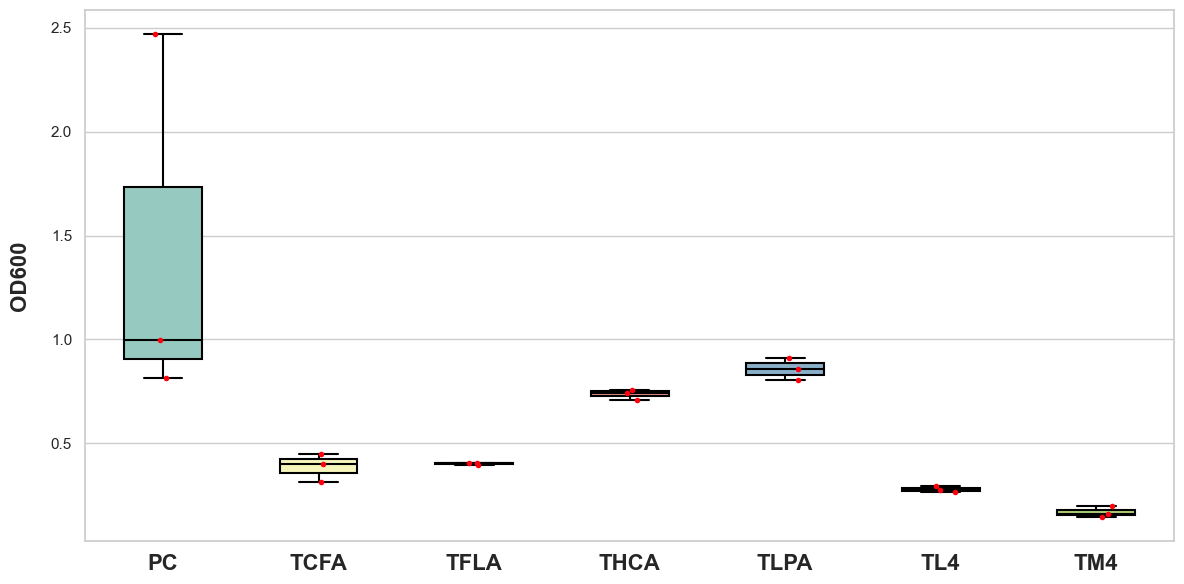

In [22]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=dg_24_clean, 
                 palette="Set3", 
                 showfliers=True, 
                 width=0.5, 
                 linewidth=1.5,
                 boxprops=dict(edgecolor='black'),       # box outline
                 whiskerprops=dict(color='black', linewidth=1.5),  # whiskers
                 capprops=dict(color='black', linewidth=1.5),      # caps
                 medianprops=dict(color='black', linewidth=1.5)    # median line
)
sns.stripplot(data=dg_24_clean, color = "#ff000d", size = 4, jitter = True)
plt.xticks(fontweight='bold', fontsize=16)
plt.ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
plt.tight_layout()
plt.show()

# Methylobacterium sp. 12 wells plate 24th hr OD600

Methylobacterium sp. was culture in 12 wells plate treated with lignin precursors caffeic acid (CFA), p-coumaric acid (HCA), ferulic acid (FLA), L-phenylalanine (LPA), coctail of the lower concentration of all four lignin precursors found in rice plant (L4), and coctail of the medium concentration of all four lignin precursors found in rice plant (M4). The OD was measured at 0 and 24th hr.

In [25]:
rc_24 = pd.read_excel('rc_24th_hr_raw_data.xlsx')
rc_24

,Samples,Water,CFA,FLA,HCA,LPA,L4,M4
0,C1,-0.003,0.063,0.002,-0.002,-0.003,0.169,0.011
1,C2,-0.004,0.064,0.007,0.000,-0.001,0.046,0.009
2,C3,0.007,0.060,0.002,0.000,-0.003,0.029,0.010
3,RC1,0.700,1.460,0.990,0.754,0.860,1.107,0.288
4,RC2,0.800,1.462,1.000,0.870,0.543,1.165,0.267
5,RC3,0.780,1.475,1.207,0.989,0.760,1.290,0.268


In [27]:
rc_24 = rc_24.rename(columns=col_map)

In [29]:
rc_24_clean = pd.DataFrame()

# Process columns 1 to 7 (Python index 1 to 7 is df.columns[1:8])
for col in rc_24.columns[1:8]:
    # Calculate the average of rows 0 to 2 (negative control)
    control_avg = rc_24[col].iloc[0:3].mean()
    
    # Subtract the control average from rows 3 to 5 (test samples)
    adjusted_values = rc_24[col].iloc[3:6] - control_avg
    
    # Add the adjusted values to the new DataFrame
    rc_24_clean[col] = adjusted_values.reset_index(drop=True)

#Print df
rc_24_clean

,PC,TCFA,TFLA,THCA,TLPA,TL4,TM4
0,0.70,1.397667,0.986333,0.754667,0.862333,1.025667,0.278
1,0.80,1.399667,0.996333,0.870667,0.545333,1.083667,0.257
2,0.78,1.412667,1.203333,0.989667,0.762333,1.208667,0.258


In [31]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in rc_24_clean.columns[0:7]:
    stat, p = shapiro(rc_24_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

PC: W=0.8929, p-value=0.3631
TCFA: W=0.8480, p-value=0.2351
TFLA: W=0.7845, p-value=0.0780
THCA: W=0.9999, p-value=0.9859
TLPA: W=0.9566, p-value=0.5990
TL4: W=0.9572, p-value=0.6022
TM4: W=0.7856, p-value=0.0806


In [33]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in rc_24_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(rc_24_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': rc_24_clean[col].iloc[i]
        })

anova_rc_24_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_rc_24_df).fit()
anova_rc_24 = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_rc_24[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_rc_24_df['OD'],
    groups=anova_rc_24_df['Treatment'],
    alpha=0.05
)

# Convert to DataFrame
tukey_df = pd.DataFrame(data=tukey_all.summary().data[1:], columns=tukey_all.summary().data[0])

# Filter to only comparisons with "Water" (or "TSB" if you want that)
water_comparisons = tukey_df[(tukey_df['group1'] == 'Water') | (tukey_df['group2'] == 'Water')]

print("\nTukey HSD Results vs Water:\n", water_comparisons)
print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df          F       p-value  Bonferroni p-value
C(Treatment)  2.328008   6.0  40.640981  4.543769e-08        4.543769e-08
Residual      0.133659  14.0        NaN           NaN                 NaN

Tukey HSD Results vs Water:
 Empty DataFrame
Columns: [group1, group2, meandiff, p-adj, lower, upper, reject]
Index: []

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    PC   TCFA   0.6433    0.0  0.3709  0.9157   True
    PC   TFLA    0.302 0.0256  0.0296  0.5744   True
    PC   THCA   0.1117 0.7935 -0.1607  0.3841  False
    PC    TL4    0.346 0.0094  0.0736  0.6184   True
    PC   TLPA  -0.0367  0.999 -0.3091  0.2357  False
    PC    TM4  -0.4957 0.0004 -0.7681 -0.2233   True
  TCFA   TFLA  -0.3413 0.0104 -0.6137 -0.0689   True
  TCFA   THCA  -0.5317 0.0002 -0.8041 -0.2593   True
  TCFA

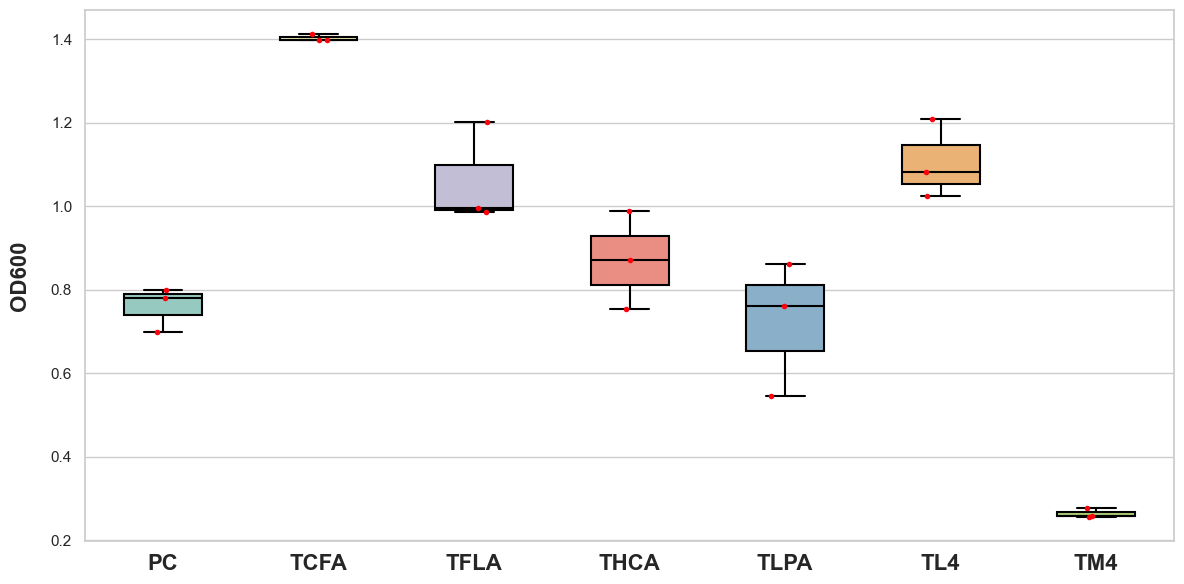

In [34]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=rc_24_clean, 
                 palette="Set3", 
                 showfliers=True, 
                 width=0.5, 
                 linewidth=1.5,
                 boxprops=dict(edgecolor='black'),       # box outline
                 whiskerprops=dict(color='black', linewidth=1.5),  # whiskers
                 capprops=dict(color='black', linewidth=1.5),      # caps
                 medianprops=dict(color='black', linewidth=1.5)    # median line
)
sns.stripplot(data=rc_24_clean, color = "#ff000d", size = 4, jitter = True)
plt.xticks(fontweight='bold', fontsize=16)
plt.ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
plt.tight_layout()
plt.show()

## Combined plot of RC and DG

C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_14296\390759254.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold', fontsize=12)
C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_14296\390759254.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), fontweight='bold', fontsize=12)


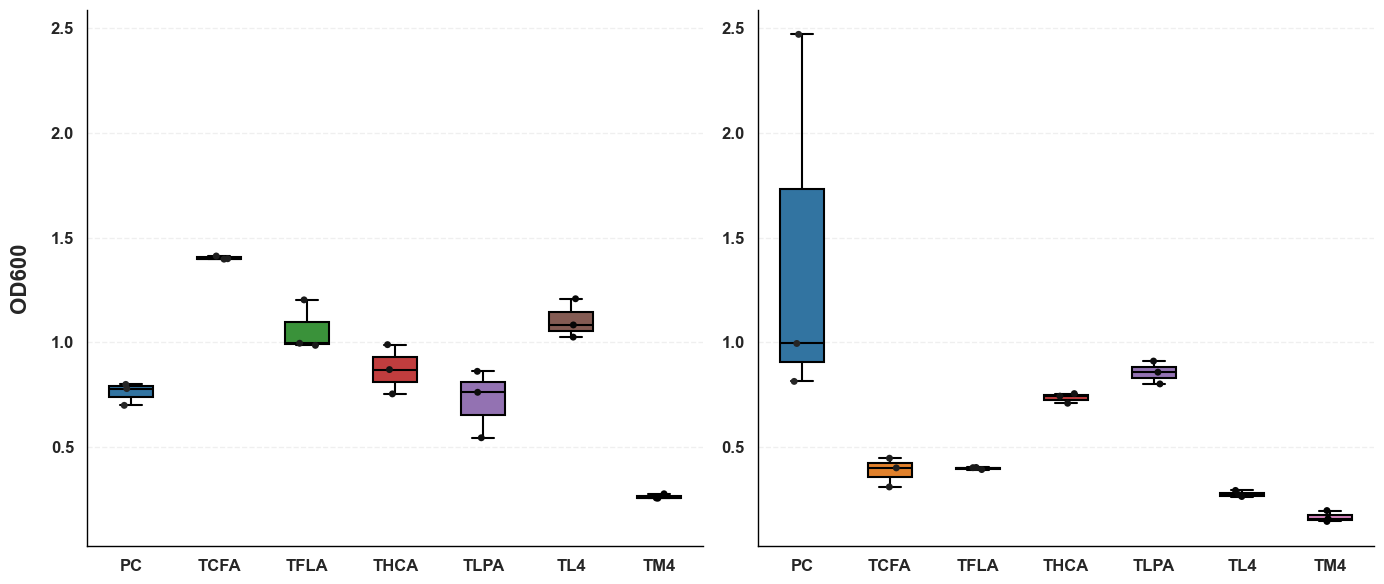

In [271]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

# Set seaborn style
sns.set(style="whitegrid")

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# First subplot: rc_24_clean
sns.boxplot(data=rc_24_clean,
            palette="tab10", 
            showfliers=True, 
            width=0.5, 
            linewidth=1.5,
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5),
            ax=axes[0]
)
sns.stripplot(data=rc_24_clean, palette="dark:black", size=5, jitter=True, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold', fontsize=12)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
axes[0].set_ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
axes[0].set_xlabel("")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(True)
axes[0].spines['bottom'].set_visible(True)
axes[0].spines['bottom'].set_linewidth(1)
axes[0].spines['bottom'].set_color("black")
axes[0].spines['left'].set_linewidth(1)
axes[0].spines['left'].set_color("black")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Second subplot: dg_24_clean
sns.boxplot(data=dg_24_clean,
            palette="tab10", 
            showfliers=True, 
            width=0.5, 
            linewidth=1.5,
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5),
            ax=axes[1]
)
sns.stripplot(data=dg_24_clean, palette="dark:black", size=5, jitter=True, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontweight='bold', fontsize=12)
axes[1].tick_params(axis='y', which='both', labelleft=True)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # No ylabel for second plot
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)
axes[1].spines['bottom'].set_linewidth(1)
axes[1].spines['bottom'].set_color("black")
axes[1].spines['left'].set_linewidth(1)
axes[1].spines['left'].set_color("black")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('RC_DG_wells.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Methylobacterium sp. Flask 24th hr OD600

Methylobacterium sp. strain was culture in 100 ml flask treated with lignin precursors caffeic acid (CFA), and  ferulic acid (FLA). The OD was measured at 0 and 24th hr.

In [41]:
rc_flask = pd.read_excel('rc_24th_hr_flask.xlsx')
rc_flask

,Samples,Water,CFA,FLA
0,RC1,0.979,0.669,0.425
1,RC2,0.926,0.663,0.542
2,RC3,1.107,0.711,0.566


In [43]:
rc_flask.drop(rc_flask.columns[0], axis=1, inplace=True)
rc_flask

,Water,CFA,FLA
0,0.979,0.669,0.425
1,0.926,0.663,0.542
2,1.107,0.711,0.566


In [47]:
rc_flask = rc_flask.rename(columns=col_map)

In [49]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in rc_flask.columns[0:3]:
    stat, p = shapiro(rc_flask[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

PC: W=0.9459, p-value=0.5515
TCFA: W=0.8421, p-value=0.2196
TFLA: W=0.8734, p-value=0.3051


In [51]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in rc_flask.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(rc_flask)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': rc_flask[col].iloc[i]
        })

anova_rc_flask_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_rc_flask_df).fit()
anova_rc_flask = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_rc_flask[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_rc_flask_df['OD'],
    groups=anova_rc_flask_df['Treatment'],
    alpha=0.05
)

# Convert to DataFrame
tukey_df = pd.DataFrame(data=tukey_all.summary().data[1:], columns=tukey_all.summary().data[0])

# Filter to only comparisons with "Water" (or "TSB" if you want that)
water_comparisons = tukey_df[(tukey_df['group1'] == 'Water') | (tukey_df['group2'] == 'Water')]

print("\nTukey HSD Results vs Water:\n", water_comparisons)
print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq   df          F   p-value  Bonferroni p-value
C(Treatment)  0.376278  2.0  37.542703  0.000405            0.000405
Residual      0.030068  6.0        NaN       NaN                 NaN

Tukey HSD Results vs Water:
 Empty DataFrame
Columns: [group1, group2, meandiff, p-adj, lower, upper, reject]
Index: []

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    PC   TCFA   -0.323 0.0034 -0.5003 -0.1457   True
    PC   TFLA   -0.493 0.0003 -0.6703 -0.3157   True
  TCFA   TFLA    -0.17 0.0585 -0.3473  0.0073  False
----------------------------------------------------


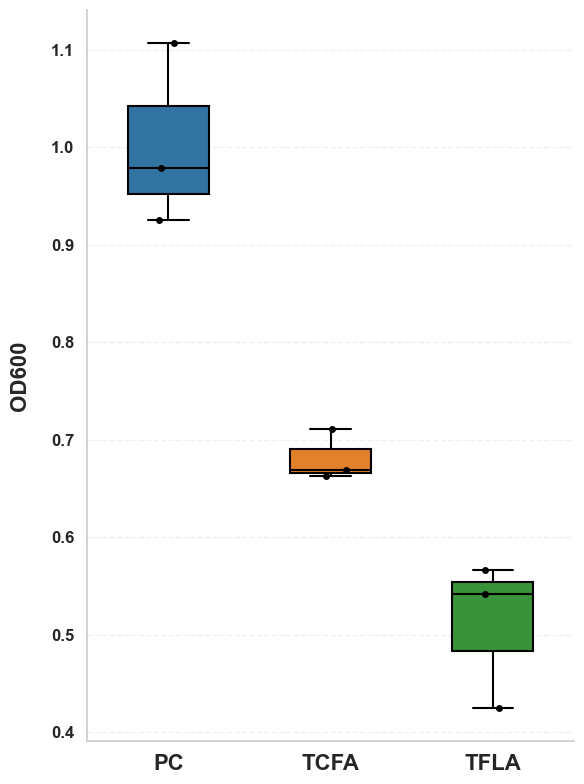

In [269]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

sns.set(style="whitegrid")
plt.figure(figsize=(6, 8))
ax = sns.boxplot(data=rc_flask, 
                 palette="tab10", 
                 showfliers=True, 
                 width=0.5, 
                 linewidth=1.5,
                 boxprops=dict(edgecolor='black'),       # box outline
                 whiskerprops=dict(color='black', linewidth=1.5),  # whiskers
                 capprops=dict(color='black', linewidth=1.5),      # caps
                 medianprops=dict(color='black', linewidth=1.5)    # median line
)
sns.stripplot(data=rc_flask, color = "black", size = 5, jitter = True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=12)
plt.ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('RC_Flask.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# CFA Plate Test

Deinococcus gobienses I-0 and Methylobacterium sp. were culture in 9 mm tryton soy agar plates treated with lignin precursors caffeic acid (CFA) and ferulic acid (FLA). A colony was transferred from untreated plate to the treatment plates and control plates. The diameter of the colonies were calculated after 5 days.

In [56]:
cfa = pd.read_excel('cfa_plate_test.xlsx')
cfa

,Sample,D1,D2,D3,D4,D5,Average
0,TRC1,0.60,0.7,0.6,0.65,0.6,0.63
1,TDG1,0.95,0.5,0.8,0.80,0.6,0.73
2,TRC2,0.60,0.7,0.4,0.60,0.5,0.56
3,TDG2,0.50,0.6,0.4,0.50,0.6,0.52
4,TRC3,0.30,0.4,0.3,0.30,0.3,0.32
5,TDG3,0.40,0.4,0.4,0.40,0.4,0.40
6,TRC4,0.60,0.7,0.6,0.60,0.6,0.62
7,TDG4,0.70,0.4,0.6,0.70,0.5,0.58
8,TRC5,0.70,0.5,0.6,0.60,0.5,0.58
9,TDG5,0.70,0.7,0.5,0.70,0.6,0.64


In [82]:
# Extract all PRC and TRC values (flatten into 1D list)
rc_control_vals = cfa[cfa['Sample'].str.startswith("PRC")].iloc[:, 6:].values.flatten()
rc_test_vals = cfa[cfa['Sample'].str.startswith("TRC")].iloc[:, 6:].values.flatten()

# Extract all PDG and TDG values (flatten into 1D list)
dg_control_vals = cfa[cfa['Sample'].str.startswith("PDG")].iloc[:, 6:].values.flatten()
dg_test_vals = cfa[cfa['Sample'].str.startswith("TDG")].iloc[:, 6:].values.flatten()

# Create new DataFrame with two rows: Control and Test
rc_cfa = pd.DataFrame(
    [rc_control_vals, rc_test_vals],
    index=['Control', 'Test']
)

# Create new DataFrame with two rows: Control and Test
dg_cfa = pd.DataFrame(
    [dg_control_vals, dg_test_vals],
    index=['Control', 'Test']
)

# Rename columns as Diameter1, Diameter2, ...
rc_cfa.columns = [f"R{i+1}" for i in range(rc_cfa.shape[1])]

# Rename columns as Diameter1, Diameter2, ...
dg_cfa.columns = [f"R{i+1}" for i in range(dg_cfa.shape[1])]

# Transpose immediately so OD replicates are rows and Control/Test are columns
rc_cfa = rc_cfa.T.reset_index().rename(columns={'index': 'Replicate'})

# Transpose immediately so OD replicates are rows and Control/Test are columns
dg_cfa = dg_cfa.T.reset_index().rename(columns={'index': 'Replicate'})

rc_cfa

,Replicate,Control,Test
0,R1,0.56,0.63
1,R2,0.58,0.56
2,R3,0.74,0.32
3,R4,0.38,0.62
4,R5,NaN,0.58


In [84]:
dg_cfa

,Replicate,Control,Test
0,R1,0.77,0.73
1,R2,0.82,0.52
2,R3,0.76,0.40
3,R4,0.50,0.58
4,R5,NaN,0.64


In [86]:
#Remove the last row with null value
rc_cfa = rc_cfa.iloc[:-1]
dg_cfa = dg_cfa.iloc[:-1]

dg_cfa

,Replicate,Control,Test
0,R1,0.77,0.73
1,R2,0.82,0.52
2,R3,0.76,0.40
3,R4,0.50,0.58


In [88]:
rc_cfa

,Replicate,Control,Test
0,R1,0.56,0.63
1,R2,0.58,0.56
2,R3,0.74,0.32
3,R4,0.38,0.62


In [90]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in rc_cfa.columns[1:3]:
    stat, p = shapiro(rc_cfa[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print
print("Methylobacterium (RC):")
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

Methylobacterium (RC):
Control: W=0.9658, p-value=0.8151
Test: W=0.7886, p-value=0.0834


In [92]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in dg_cfa.columns[1:3]:
    stat, p = shapiro(dg_cfa[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print
print("Deinococcus gobiensis I-0 (DG):")
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

Deinococcus gobiensis I-0 (DG):
Control: W=0.7885, p-value=0.0831
Test: W=0.9927, p-value=0.9709


In [94]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in rc_cfa.columns[1:3]:  # treatments are columns 1–7
    for i in range(len(rc_cfa)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': rc_cfa[col].iloc[i]
        })

anova_rc_cfa_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_rc_cfa_df).fit()
anova_rc_cfa = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_rc_cfa[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction for Methylobacterium sp.:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_rc_cfa_df['OD'],
    groups=anova_rc_cfa_df['Treatment'],
    alpha=0.05
)

print("\nTukey HSD Results for Methylobacterium sp.:\n", tukey_all)


One-way ANOVA with Bonferroni correction for Methylobacterium sp.:
                sum_sq   df         F   p-value  Bonferroni p-value
C(Treatment)  0.002113  1.0  0.098888  0.763816            0.763816
Residual      0.128175  6.0       NaN       NaN                 NaN

Tukey HSD Results for Methylobacterium sp.:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Control   Test  -0.0325 0.7638 -0.2854 0.2204  False
----------------------------------------------------


In [96]:
# One way ANOVA testing for RC
# Prepare data for one-way ANOVA
data = []
for col in dg_cfa.columns[1:3]:  # treatments are columns 1–7
    for i in range(len(dg_cfa)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': dg_cfa[col].iloc[i]
        })

anova_dg_cfa_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_dg_cfa_df).fit()
anova_dg_cfa = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_dg_cfa[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction for Deinococcus Gobiensis I-0:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_dg_cfa_df['OD'],
    groups=anova_dg_cfa_df['Treatment'],
    alpha=0.05
)

print("\nTukey HSD Results for Deinococcus Gobiensis I-0:\n", tukey_all)


One-way ANOVA with Bonferroni correction for Deinococcus Gobiensis I-0:
               sum_sq   df         F   p-value  Bonferroni p-value
C(Treatment)  0.04805  1.0  2.427789  0.170212            0.170212
Residual      0.11875  6.0       NaN       NaN                 NaN

Tukey HSD Results for Deinococcus Gobiensis I-0:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Control   Test   -0.155 0.1702 -0.3984 0.0884  False
----------------------------------------------------


In [98]:
# One way ANOVA testing for DG
# Prepare data for one-way ANOVA
data = []
for col in dg_cfa.columns[1:3]:  # treatments are columns 1–7
    for i in range(len(dg_cfa)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': dg_cfa[col].iloc[i]
        })

anova_dg_cfa_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_dg_cfa_df).fit()
anova_dg_cfa = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_dg_cfa[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_dg_cfa_df['OD'],
    groups=anova_dg_cfa_df['Treatment'],
    alpha=0.05
)

print("\nTukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
               sum_sq   df         F   p-value  Bonferroni p-value
C(Treatment)  0.04805  1.0  2.427789  0.170212            0.170212
Residual      0.11875  6.0       NaN       NaN                 NaN

Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Control   Test   -0.155 0.1702 -0.3984 0.0884  False
----------------------------------------------------


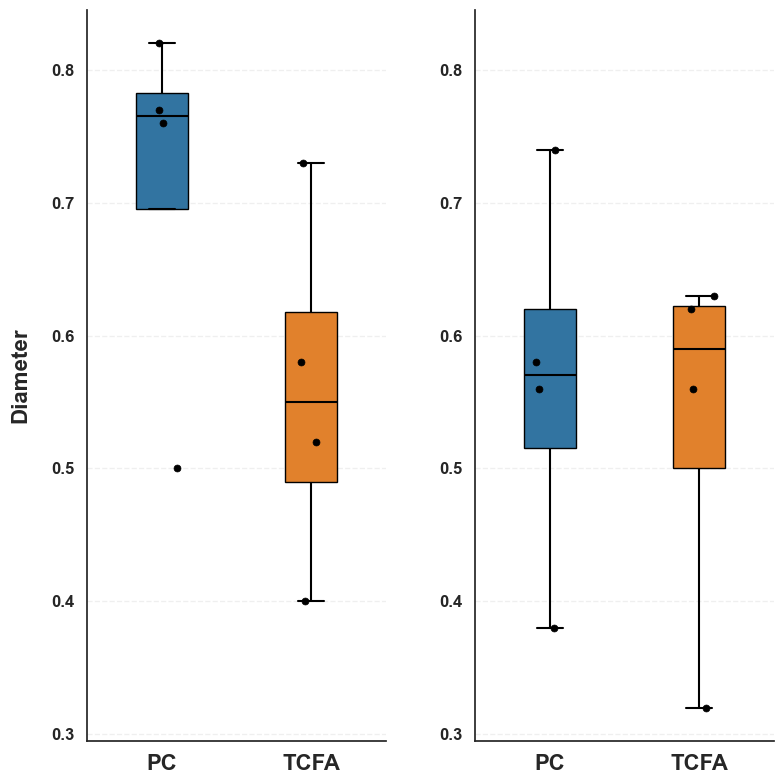

In [267]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

# Label map and colors
label_map = {"Control": "PC", "Test": "TCFA"}
treatment_colors = {"PC": "#1f77b4", "TCFA": "#ff7f0e"}

# Prepare long format data
def prepare_long_df(data):
    subset = data.iloc[:, 1:3]
    long_df = subset.melt(var_name="Group", value_name="Diameter")
    long_df["Treatment"] = long_df["Group"].map(label_map)
    return long_df

dg_long = prepare_long_df(dg_cfa)
rc_long = prepare_long_df(rc_cfa)

# Create subplots
sns.set(style="white")
fig, axes = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

# Function to plot each subplot
def plot_subplot(ax, data, label):
    for i, treatment in enumerate(["PC", "TCFA"]):
        sns.boxplot(
            x="Treatment", y="Diameter", data=data[data["Treatment"] == treatment],
            ax=ax, width=0.35, showfliers=False,
            color=treatment_colors[treatment],
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5)
        )
    sns.stripplot(
        x="Treatment", y="Diameter", data=data,
        ax=ax, color='black', size=5, jitter=0.1,
        edgecolor='black', linewidth=0.5
    )
    ax.set_xlabel("")
    # Show x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["PC", "TCFA"], fontsize=16, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.tick_params(axis='y', which='both', labelleft=True)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(12)


# Plot DG
plot_subplot(axes[0], dg_long, "DG")
axes[0].set_ylabel("Diameter", fontweight='bold', fontsize=16, labelpad=15)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Plot RC
plot_subplot(axes[1], rc_long, "RC")
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.savefig("DG_RC_plate.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

# Growth Kinetics

Deinococcus gobienses I-0 strain and Methylobacterium sp. were cultured in 96 wells plate treated with lignin precursors caffeic acid (CFA), p-coumaric acid (HCA), ferulic acid (FLA), L-phenylalanine (LPA), coctail of the lower concentration of all four lignin precursors found in rice plant (L4), and coctail of the medium concentration of all four lignin precursors found in rice plant (M4). The OD was measured at every 30 mins interval for 24 hrs.

In [102]:
gk = pd.read_excel('day1_growth_kinetics.xlsx')
gk

,Well,Content,Group,Raw Data (600),Raw Data (600).1,Raw Data (600).2,Raw Data (600).3,Raw Data (600).4,Raw Data (600).5,Raw Data (600).6,...,Raw Data (600).39,Raw Data (600).40,Raw Data (600).41,Raw Data (600).42,Raw Data (600).43,Raw Data (600).44,Raw Data (600).45,Raw Data (600).46,Raw Data (600).47,Raw Data (600).48
0,NaN,Time,NaN,00:00:00,00:30:00,01:00:00,01:30:00,02:00:00,02:30:00,03:00:00,...,19:30:00,20:00:00,20:30:00,21:00:00,21:30:00,22:00:00,22:30:00,23:00:00,23:30:00,NaN
1,A01,Blank B,A,0.314,0.377,0.38,0.385,0.387,0.391,0.394,...,0.42,0.419,0.42,0.424,0.424,0.424,0.42,0.421,0.423,0.422
2,A02,Blank B,A,0.339,0.378,0.385,0.387,0.386,0.389,0.4,...,0.404,0.408,0.406,0.412,0.414,0.411,0.41,0.411,0.412,0.410
3,A03,Blank B,A,0.346,0.377,0.384,0.389,0.387,0.388,0.391,...,0.409,0.41,0.408,0.413,0.412,0.415,0.412,0.412,0.416,0.413
4,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,H08,Sample X10,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
88,H09,Sample X14,C,0.411,0.408,0.413,0.41,0.412,0.412,0.421,...,0.43,0.43,0.428,0.431,0.431,0.43,0.431,0.428,0.433,0.433
89,H10,Sample X15,C,0.496,0.491,0.492,0.493,0.494,0.496,0.495,...,0.584,0.59,0.591,0.593,0.597,0.606,0.604,0.609,0.615,0.619
90,H11,Sample X9,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552


In [104]:
gk.iloc[0, 0] = "Well"
gk.iloc[0, 1] = "Content"
gk.iloc[0, 2] = "Group"
gk

,Well,Content,Group,Raw Data (600),Raw Data (600).1,Raw Data (600).2,Raw Data (600).3,Raw Data (600).4,Raw Data (600).5,Raw Data (600).6,...,Raw Data (600).39,Raw Data (600).40,Raw Data (600).41,Raw Data (600).42,Raw Data (600).43,Raw Data (600).44,Raw Data (600).45,Raw Data (600).46,Raw Data (600).47,Raw Data (600).48
0,Well,Content,Group,00:00:00,00:30:00,01:00:00,01:30:00,02:00:00,02:30:00,03:00:00,...,19:30:00,20:00:00,20:30:00,21:00:00,21:30:00,22:00:00,22:30:00,23:00:00,23:30:00,NaN
1,A01,Blank B,A,0.314,0.377,0.38,0.385,0.387,0.391,0.394,...,0.42,0.419,0.42,0.424,0.424,0.424,0.42,0.421,0.423,0.422
2,A02,Blank B,A,0.339,0.378,0.385,0.387,0.386,0.389,0.4,...,0.404,0.408,0.406,0.412,0.414,0.411,0.41,0.411,0.412,0.410
3,A03,Blank B,A,0.346,0.377,0.384,0.389,0.387,0.388,0.391,...,0.409,0.41,0.408,0.413,0.412,0.415,0.412,0.412,0.416,0.413
4,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,H08,Sample X10,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
88,H09,Sample X14,C,0.411,0.408,0.413,0.41,0.412,0.412,0.421,...,0.43,0.43,0.428,0.431,0.431,0.43,0.431,0.428,0.433,0.433
89,H10,Sample X15,C,0.496,0.491,0.492,0.493,0.494,0.496,0.495,...,0.584,0.59,0.591,0.593,0.597,0.606,0.604,0.609,0.615,0.619
90,H11,Sample X9,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552


In [107]:
time_points = np.arange(0, 24.5, 0.5)

# Assign to gk
gk.iloc[0, 3:3+len(time_points)] = time_points
gk

,Well,Content,Group,Raw Data (600),Raw Data (600).1,Raw Data (600).2,Raw Data (600).3,Raw Data (600).4,Raw Data (600).5,Raw Data (600).6,...,Raw Data (600).39,Raw Data (600).40,Raw Data (600).41,Raw Data (600).42,Raw Data (600).43,Raw Data (600).44,Raw Data (600).45,Raw Data (600).46,Raw Data (600).47,Raw Data (600).48
0,Well,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.000
1,A01,Blank B,A,0.314,0.377,0.38,0.385,0.387,0.391,0.394,...,0.42,0.419,0.42,0.424,0.424,0.424,0.42,0.421,0.423,0.422
2,A02,Blank B,A,0.339,0.378,0.385,0.387,0.386,0.389,0.4,...,0.404,0.408,0.406,0.412,0.414,0.411,0.41,0.411,0.412,0.410
3,A03,Blank B,A,0.346,0.377,0.384,0.389,0.387,0.388,0.391,...,0.409,0.41,0.408,0.413,0.412,0.415,0.412,0.412,0.416,0.413
4,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,H08,Sample X10,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
88,H09,Sample X14,C,0.411,0.408,0.413,0.41,0.412,0.412,0.421,...,0.43,0.43,0.428,0.431,0.431,0.43,0.431,0.428,0.433,0.433
89,H10,Sample X15,C,0.496,0.491,0.492,0.493,0.494,0.496,0.495,...,0.584,0.59,0.591,0.593,0.597,0.606,0.604,0.609,0.615,0.619
90,H11,Sample X9,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552


In [109]:
gk.columns = gk.iloc[0]
gk = gk.drop(index=0)
gk

,Well,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
1,A01,Blank B,A,0.314,0.377,0.38,0.385,0.387,0.391,0.394,...,0.42,0.419,0.42,0.424,0.424,0.424,0.42,0.421,0.423,0.422
2,A02,Blank B,A,0.339,0.378,0.385,0.387,0.386,0.389,0.4,...,0.404,0.408,0.406,0.412,0.414,0.411,0.41,0.411,0.412,0.410
3,A03,Blank B,A,0.346,0.377,0.384,0.389,0.387,0.388,0.391,...,0.409,0.41,0.408,0.413,0.412,0.415,0.412,0.412,0.416,0.413
4,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
5,A05,Sample X2,A,0.512,0.515,0.517,0.519,0.524,0.528,0.54,...,0.69,0.689,0.688,0.687,0.699,0.706,0.701,0.708,0.706,0.710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,H08,Sample X10,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
88,H09,Sample X14,C,0.411,0.408,0.413,0.41,0.412,0.412,0.421,...,0.43,0.43,0.428,0.431,0.431,0.43,0.431,0.428,0.433,0.433
89,H10,Sample X15,C,0.496,0.491,0.492,0.493,0.494,0.496,0.495,...,0.584,0.59,0.591,0.593,0.597,0.606,0.604,0.609,0.615,0.619
90,H11,Sample X9,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552


In [111]:
gk = gk.sort_values(by=['Group', 'Content', 'Well'], ascending=[True, True, True])
gk

,Well,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
1,A01,Blank B,A,0.314,0.377,0.38,0.385,0.387,0.391,0.394,...,0.42,0.419,0.42,0.424,0.424,0.424,0.42,0.421,0.423,0.422
2,A02,Blank B,A,0.339,0.378,0.385,0.387,0.386,0.389,0.4,...,0.404,0.408,0.406,0.412,0.414,0.411,0.41,0.411,0.412,0.410
3,A03,Blank B,A,0.346,0.377,0.384,0.389,0.387,0.388,0.391,...,0.409,0.41,0.408,0.413,0.412,0.415,0.412,0.412,0.416,0.413
4,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
91,H12,Sample X10,A,0.421,0.431,0.441,0.445,0.45,0.448,0.453,...,0.522,0.522,0.525,0.529,0.534,0.534,0.532,0.535,0.545,0.545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,G08,Sample X5,G,0.523,0.561,0.571,0.571,0.571,0.574,0.573,...,0.585,0.594,0.594,0.596,0.597,0.585,0.598,0.596,0.593,0.590
64,F09,Sample X6,G,0.445,0.437,0.436,0.438,0.44,0.441,0.439,...,0.47,0.476,0.468,0.474,0.475,0.468,0.477,0.48,0.484,0.484
65,F10,Sample X7,G,0.445,0.44,0.436,0.439,0.451,0.448,0.446,...,0.485,0.487,0.484,0.488,0.487,0.479,0.485,0.492,0.494,0.499
66,F11,Sample X8,G,0.453,0.444,0.444,0.448,0.455,0.459,0.453,...,0.497,0.498,0.493,0.501,0.504,0.492,0.503,0.512,0.511,0.513


In [113]:
gk["Content"].unique()

array(['Blank B', 'Sample X1', 'Sample X10', 'Sample X2', 'Sample X3',
       'Sample X4', 'Sample X5', 'Sample X6', 'Sample X7', 'Sample X8',
       'Sample X9', 'Sample X11', 'Sample X12', 'Sample X13',
       'Sample X14', 'Sample X15'], dtype=object)

In [115]:
# Getting Blanks
blanks = gk[gk["Content"] =="Blank B"]

# Separating numeric and non-numeric columns
numeric_cols = time_points
non_numeric_cols = ["Well", "Content", "Group"]

# Averaging the numeric cols
blank = blanks.groupby("Group").agg(
    {**{col: "mean" for col in numeric_cols},
    **{col: "first" for col in non_numeric_cols}}
).reset_index(drop=True)

blank

,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,...,21.0,21.5,22.0,22.5,23.0,23.5,24.0,Well,Content,Group
0,0.333,0.377333,0.383,0.387,0.386667,0.389333,0.395,0.392667,0.391333,0.390667,...,0.416333,0.416667,0.416667,0.414,0.414667,0.417,0.415000,A01,Blank B,A
1,0.395,0.406667,0.412,0.414667,0.414667,0.414667,0.411333,0.412667,0.413667,0.417333,...,0.426667,0.428333,0.428,0.426667,0.426,0.427333,0.428667,B01,Blank B,B
2,0.390333,0.398667,0.398333,0.398667,0.395,0.399,0.397,0.397667,0.398,0.397333,...,0.401,0.400667,0.401333,0.398667,0.401333,0.399667,0.401667,C01,Blank B,C
3,0.393,0.394667,0.396,0.401333,0.401667,0.399333,0.399667,0.399667,0.398667,0.398333,...,0.404333,0.405333,0.402,0.403667,0.405667,0.401,0.405000,D01,Blank B,D
4,0.398,0.399333,0.403667,0.399333,0.402,0.403667,0.400333,0.400667,0.401333,0.402,...,0.404667,0.404667,0.404667,0.406,0.406,0.405,0.406333,E01,Blank B,E
5,0.405333,0.404667,0.405333,0.408,0.406333,0.407667,0.407667,0.409333,0.408667,0.412667,...,0.413667,0.412333,0.409,0.409667,0.411667,0.414333,0.414333,F01,Blank B,F
6,0.395,0.405667,0.404667,0.396333,0.397667,0.398667,0.400333,0.401333,0.399333,0.399333,...,0.404667,0.404,0.397667,0.403,0.401,0.399,0.401333,G01,Blank B,G


In [117]:
blank.drop(columns=["Well"], inplace=True)
blank

,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,...,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0,Content,Group
0,0.333,0.377333,0.383,0.387,0.386667,0.389333,0.395,0.392667,0.391333,0.390667,...,0.411333,0.416333,0.416667,0.416667,0.414,0.414667,0.417,0.415000,Blank B,A
1,0.395,0.406667,0.412,0.414667,0.414667,0.414667,0.411333,0.412667,0.413667,0.417333,...,0.424333,0.426667,0.428333,0.428,0.426667,0.426,0.427333,0.428667,Blank B,B
2,0.390333,0.398667,0.398333,0.398667,0.395,0.399,0.397,0.397667,0.398,0.397333,...,0.399333,0.401,0.400667,0.401333,0.398667,0.401333,0.399667,0.401667,Blank B,C
3,0.393,0.394667,0.396,0.401333,0.401667,0.399333,0.399667,0.399667,0.398667,0.398333,...,0.405333,0.404333,0.405333,0.402,0.403667,0.405667,0.401,0.405000,Blank B,D
4,0.398,0.399333,0.403667,0.399333,0.402,0.403667,0.400333,0.400667,0.401333,0.402,...,0.404333,0.404667,0.404667,0.404667,0.406,0.406,0.405,0.406333,Blank B,E
5,0.405333,0.404667,0.405333,0.408,0.406333,0.407667,0.407667,0.409333,0.408667,0.412667,...,0.409333,0.413667,0.412333,0.409,0.409667,0.411667,0.414333,0.414333,Blank B,F
6,0.395,0.405667,0.404667,0.396333,0.397667,0.398667,0.400333,0.401333,0.399333,0.399333,...,0.407333,0.404667,0.404,0.397667,0.403,0.401,0.399,0.401333,Blank B,G


In [119]:
# Re-order the column header
new_order = ["Content", "Group"] + list(time_points)
blank = blank[new_order]
blank

,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,Blank B,A,0.333,0.377333,0.383,0.387,0.386667,0.389333,0.395,0.392667,...,0.411,0.412333,0.411333,0.416333,0.416667,0.416667,0.414,0.414667,0.417,0.415000
1,Blank B,B,0.395,0.406667,0.412,0.414667,0.414667,0.414667,0.411333,0.412667,...,0.427333,0.425,0.424333,0.426667,0.428333,0.428,0.426667,0.426,0.427333,0.428667
2,Blank B,C,0.390333,0.398667,0.398333,0.398667,0.395,0.399,0.397,0.397667,...,0.401,0.4,0.399333,0.401,0.400667,0.401333,0.398667,0.401333,0.399667,0.401667
3,Blank B,D,0.393,0.394667,0.396,0.401333,0.401667,0.399333,0.399667,0.399667,...,0.403667,0.403,0.405333,0.404333,0.405333,0.402,0.403667,0.405667,0.401,0.405000
4,Blank B,E,0.398,0.399333,0.403667,0.399333,0.402,0.403667,0.400333,0.400667,...,0.407,0.405667,0.404333,0.404667,0.404667,0.404667,0.406,0.406,0.405,0.406333
5,Blank B,F,0.405333,0.404667,0.405333,0.408,0.406333,0.407667,0.407667,0.409333,...,0.412333,0.414,0.409333,0.413667,0.412333,0.409,0.409667,0.411667,0.414333,0.414333
6,Blank B,G,0.395,0.405667,0.404667,0.396333,0.397667,0.398667,0.400333,0.401333,...,0.401667,0.405667,0.407333,0.404667,0.404,0.397667,0.403,0.401,0.399,0.401333


In [121]:
blank.drop(columns=["Content"], inplace=True)
blank

C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_14296\2828309284.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  blank.drop(columns=["Content"], inplace=True)


,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A,0.333,0.377333,0.383,0.387,0.386667,0.389333,0.395,0.392667,0.391333,...,0.411,0.412333,0.411333,0.416333,0.416667,0.416667,0.414,0.414667,0.417,0.415000
1,B,0.395,0.406667,0.412,0.414667,0.414667,0.414667,0.411333,0.412667,0.413667,...,0.427333,0.425,0.424333,0.426667,0.428333,0.428,0.426667,0.426,0.427333,0.428667
2,C,0.390333,0.398667,0.398333,0.398667,0.395,0.399,0.397,0.397667,0.398,...,0.401,0.4,0.399333,0.401,0.400667,0.401333,0.398667,0.401333,0.399667,0.401667
3,D,0.393,0.394667,0.396,0.401333,0.401667,0.399333,0.399667,0.399667,0.398667,...,0.403667,0.403,0.405333,0.404333,0.405333,0.402,0.403667,0.405667,0.401,0.405000
4,E,0.398,0.399333,0.403667,0.399333,0.402,0.403667,0.400333,0.400667,0.401333,...,0.407,0.405667,0.404333,0.404667,0.404667,0.404667,0.406,0.406,0.405,0.406333
5,F,0.405333,0.404667,0.405333,0.408,0.406333,0.407667,0.407667,0.409333,0.408667,...,0.412333,0.414,0.409333,0.413667,0.412333,0.409,0.409667,0.411667,0.414333,0.414333
6,G,0.395,0.405667,0.404667,0.396333,0.397667,0.398667,0.400333,0.401333,0.399333,...,0.401667,0.405667,0.407333,0.404667,0.404,0.397667,0.403,0.401,0.399,0.401333


In [123]:
# Subset gk for DG
dg_gk = gk[gk["Content"].isin([f"Sample X{i}" for i in range(1, 6)])].reset_index(drop=True)
dg_gk

,Well,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A04,Sample X1,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
1,A05,Sample X2,A,0.512,0.515,0.517,0.519,0.524,0.528,0.54,...,0.69,0.689,0.688,0.687,0.699,0.706,0.701,0.708,0.706,0.710
2,A06,Sample X3,A,0.48,0.483,0.487,0.497,0.496,0.501,0.503,...,0.644,0.645,0.644,0.642,0.648,0.656,0.654,0.659,0.654,0.659
3,A07,Sample X4,A,0.486,0.487,0.491,0.497,0.502,0.505,0.507,...,0.638,0.639,0.64,0.644,0.649,0.653,0.649,0.653,0.653,0.657
4,A08,Sample X5,A,0.492,0.494,0.498,0.499,0.495,0.502,0.505,...,0.631,0.635,0.637,0.643,0.652,0.651,0.65,0.651,0.65,0.655
5,B04,Sample X1,B,0.495,0.506,0.513,0.524,0.526,0.532,0.535,...,0.594,0.591,0.59,0.593,0.595,0.595,0.591,0.591,0.593,0.594
6,B05,Sample X2,B,0.507,0.518,0.519,0.523,0.526,0.531,0.533,...,0.602,0.598,0.598,0.6,0.603,0.601,0.602,0.602,0.603,0.605
7,B06,Sample X3,B,0.512,0.523,0.528,0.534,0.536,0.546,0.543,...,0.606,0.61,0.608,0.61,0.615,0.615,0.613,0.613,0.616,0.618
8,B07,Sample X4,B,0.491,0.504,0.513,0.511,0.522,0.53,0.534,...,0.604,0.607,0.603,0.609,0.609,0.608,0.609,0.609,0.613,0.611
9,B08,Sample X5,B,0.495,0.509,0.517,0.516,0.522,0.532,0.537,...,0.604,0.602,0.599,0.603,0.606,0.605,0.605,0.605,0.606,0.608


In [125]:
# Subset gk for RC
rc_gk = gk[gk["Content"].isin([f"Sample X{i}" for i in range(6, 16)])].reset_index(drop=True)
rc_gk

,Well,Content,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,H12,Sample X10,A,0.421,0.431,0.441,0.445,0.45,0.448,0.453,...,0.522,0.522,0.525,0.529,0.534,0.534,0.532,0.535,0.545,0.545
1,G09,Sample X6,A,0.454,0.452,0.457,0.461,0.465,0.467,0.468,...,0.568,0.582,0.584,0.59,0.594,0.594,0.602,0.607,0.608,0.615
2,G10,Sample X7,A,0.441,0.443,0.443,0.442,0.448,0.451,0.452,...,0.548,0.554,0.56,0.565,0.57,0.562,0.576,0.579,0.584,0.589
3,G11,Sample X8,A,0.454,0.456,0.459,0.458,0.463,0.464,0.465,...,0.554,0.565,0.568,0.577,0.583,0.582,0.589,0.595,0.595,0.601
4,H11,Sample X9,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552
5,H08,Sample X10,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
6,H04,Sample X6,B,0.452,0.456,0.465,0.463,0.47,0.469,0.474,...,0.576,0.58,0.585,0.587,0.591,0.594,0.599,0.604,0.612,0.613
7,H05,Sample X7,B,0.455,0.451,0.46,0.46,0.463,0.468,0.469,...,0.57,0.573,0.576,0.579,0.583,0.591,0.592,0.593,0.6,0.604
8,H06,Sample X8,B,0.456,0.456,0.462,0.459,0.465,0.465,0.469,...,0.569,0.573,0.576,0.58,0.585,0.59,0.595,0.595,0.604,0.609
9,H07,Sample X9,B,0.453,0.452,0.457,0.456,0.461,0.46,0.465,...,0.552,0.555,0.56,0.564,0.568,0.57,0.575,0.577,0.588,0.590


In [127]:
dg_gk.drop(columns=["Content", "Well"], inplace=True)
dg_gk

,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A,0.485,0.49,0.501,0.509,0.505,0.51,0.518,0.517,0.52,...,0.637,0.645,0.643,0.652,0.654,0.655,0.647,0.653,0.654,0.660
1,A,0.512,0.515,0.517,0.519,0.524,0.528,0.54,0.54,0.546,...,0.69,0.689,0.688,0.687,0.699,0.706,0.701,0.708,0.706,0.710
2,A,0.48,0.483,0.487,0.497,0.496,0.501,0.503,0.505,0.508,...,0.644,0.645,0.644,0.642,0.648,0.656,0.654,0.659,0.654,0.659
3,A,0.486,0.487,0.491,0.497,0.502,0.505,0.507,0.504,0.508,...,0.638,0.639,0.64,0.644,0.649,0.653,0.649,0.653,0.653,0.657
4,A,0.492,0.494,0.498,0.499,0.495,0.502,0.505,0.505,0.509,...,0.631,0.635,0.637,0.643,0.652,0.651,0.65,0.651,0.65,0.655
5,B,0.495,0.506,0.513,0.524,0.526,0.532,0.535,0.539,0.545,...,0.594,0.591,0.59,0.593,0.595,0.595,0.591,0.591,0.593,0.594
6,B,0.507,0.518,0.519,0.523,0.526,0.531,0.533,0.537,0.541,...,0.602,0.598,0.598,0.6,0.603,0.601,0.602,0.602,0.603,0.605
7,B,0.512,0.523,0.528,0.534,0.536,0.546,0.543,0.547,0.555,...,0.606,0.61,0.608,0.61,0.615,0.615,0.613,0.613,0.616,0.618
8,B,0.491,0.504,0.513,0.511,0.522,0.53,0.534,0.541,0.544,...,0.604,0.607,0.603,0.609,0.609,0.608,0.609,0.609,0.613,0.611
9,B,0.495,0.509,0.517,0.516,0.522,0.532,0.537,0.541,0.543,...,0.604,0.602,0.599,0.603,0.606,0.605,0.605,0.605,0.606,0.608


In [129]:
rc_gk.drop(columns=["Content", "Well"], inplace=True)
rc_gk

,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A,0.421,0.431,0.441,0.445,0.45,0.448,0.453,0.451,0.448,...,0.522,0.522,0.525,0.529,0.534,0.534,0.532,0.535,0.545,0.545
1,A,0.454,0.452,0.457,0.461,0.465,0.467,0.468,0.471,0.472,...,0.568,0.582,0.584,0.59,0.594,0.594,0.602,0.607,0.608,0.615
2,A,0.441,0.443,0.443,0.442,0.448,0.451,0.452,0.452,0.453,...,0.548,0.554,0.56,0.565,0.57,0.562,0.576,0.579,0.584,0.589
3,A,0.454,0.456,0.459,0.458,0.463,0.464,0.465,0.467,0.468,...,0.554,0.565,0.568,0.577,0.583,0.582,0.589,0.595,0.595,0.601
4,A,0.444,0.443,0.449,0.449,0.449,0.451,0.45,0.453,0.45,...,0.523,0.526,0.527,0.533,0.537,0.537,0.539,0.543,0.551,0.552
5,B,0.441,0.441,0.448,0.449,0.455,0.457,0.461,0.459,0.459,...,0.54,0.543,0.546,0.548,0.556,0.561,0.562,0.56,0.566,0.568
6,B,0.452,0.456,0.465,0.463,0.47,0.469,0.474,0.474,0.473,...,0.576,0.58,0.585,0.587,0.591,0.594,0.599,0.604,0.612,0.613
7,B,0.455,0.451,0.46,0.46,0.463,0.468,0.469,0.466,0.469,...,0.57,0.573,0.576,0.579,0.583,0.591,0.592,0.593,0.6,0.604
8,B,0.456,0.456,0.462,0.459,0.465,0.465,0.469,0.47,0.467,...,0.569,0.573,0.576,0.58,0.585,0.59,0.595,0.595,0.604,0.609
9,B,0.453,0.452,0.457,0.456,0.461,0.46,0.465,0.465,0.464,...,0.552,0.555,0.56,0.564,0.568,0.57,0.575,0.577,0.588,0.590


In [131]:
#Blank correction for DG
#Identify the numeric column of DG
numeric_cols = dg_gk.columns.difference(["Group"])

# List to store results
results = []

for i, row1 in dg_gk.iterrows():
    group = row1["Group"]
    matching_rows = blank[blank["Group"] == group]
    for j, row2 in matching_rows.iterrows():
        diff = row1.copy()
        diff[numeric_cols] = row1[numeric_cols] - row2[numeric_cols]
        results.append(diff)

# Combine all results
dg_diff = pd.DataFrame(results).reset_index(drop=True)
dg_diff

,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A,0.152000,0.112667,0.118000,0.122000,0.118333,0.120667,0.123000,0.124333,0.128667,...,0.226000,0.232667,0.231667,0.235667,0.237333,0.238333,0.233000,0.238333,0.237000,0.245000
1,A,0.179000,0.137667,0.134000,0.132000,0.137333,0.138667,0.145000,0.147333,0.154667,...,0.279000,0.276667,0.276667,0.270667,0.282333,0.289333,0.287000,0.293333,0.289000,0.295000
2,A,0.147000,0.105667,0.104000,0.110000,0.109333,0.111667,0.108000,0.112333,0.116667,...,0.233000,0.232667,0.232667,0.225667,0.231333,0.239333,0.240000,0.244333,0.237000,0.244000
3,A,0.153000,0.109667,0.108000,0.110000,0.115333,0.115667,0.112000,0.111333,0.116667,...,0.227000,0.226667,0.228667,0.227667,0.232333,0.236333,0.235000,0.238333,0.236000,0.242000
4,A,0.159000,0.116667,0.115000,0.112000,0.108333,0.112667,0.110000,0.112333,0.117667,...,0.220000,0.222667,0.225667,0.226667,0.235333,0.234333,0.236000,0.236333,0.233000,0.240000
5,B,0.100000,0.099333,0.101000,0.109333,0.111333,0.117333,0.123667,0.126333,0.131333,...,0.166667,0.166000,0.165667,0.166333,0.166667,0.167000,0.164333,0.165000,0.165667,0.165333
6,B,0.112000,0.111333,0.107000,0.108333,0.111333,0.116333,0.121667,0.124333,0.127333,...,0.174667,0.173000,0.173667,0.173333,0.174667,0.173000,0.175333,0.176000,0.175667,0.176333
7,B,0.117000,0.116333,0.116000,0.119333,0.121333,0.131333,0.131667,0.134333,0.141333,...,0.178667,0.185000,0.183667,0.183333,0.186667,0.187000,0.186333,0.187000,0.188667,0.189333
8,B,0.096000,0.097333,0.101000,0.096333,0.107333,0.115333,0.122667,0.128333,0.130333,...,0.176667,0.182000,0.178667,0.182333,0.180667,0.180000,0.182333,0.183000,0.185667,0.182333
9,B,0.100000,0.102333,0.105000,0.101333,0.107333,0.117333,0.125667,0.128333,0.129333,...,0.176667,0.177000,0.174667,0.176333,0.177667,0.177000,0.178333,0.179000,0.178667,0.179333


In [133]:
#Blank correction for DG
#Identify the numeric column of DG
numeric_cols = rc_gk.columns.difference(["Group"])

# List to store results
results = []

for i, row1 in rc_gk.iterrows():
    group = row1["Group"]
    matching_rows = blank[blank["Group"] == group]
    for j, row2 in matching_rows.iterrows():
        diff = row1.copy()
        diff[numeric_cols] = row1[numeric_cols] - row2[numeric_cols]
        results.append(diff)

# Combine all results
rc_diff = pd.DataFrame(results).reset_index(drop=True)
rc_diff

,Group,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,...,19.5,20.0,20.5,21.0,21.5,22.0,22.5,23.0,23.5,24.0
0,A,0.088000,0.053667,0.058000,0.058000,0.063333,0.058667,0.058000,0.058333,0.056667,...,0.111000,0.109667,0.113667,0.112667,0.117333,0.117333,0.118000,0.120333,0.128000,0.130000
1,A,0.121000,0.074667,0.074000,0.074000,0.078333,0.077667,0.073000,0.078333,0.080667,...,0.157000,0.169667,0.172667,0.173667,0.177333,0.177333,0.188000,0.192333,0.191000,0.200000
2,A,0.108000,0.065667,0.060000,0.055000,0.061333,0.061667,0.057000,0.059333,0.061667,...,0.137000,0.141667,0.148667,0.148667,0.153333,0.145333,0.162000,0.164333,0.167000,0.174000
3,A,0.121000,0.078667,0.076000,0.071000,0.076333,0.074667,0.070000,0.074333,0.076667,...,0.143000,0.152667,0.156667,0.160667,0.166333,0.165333,0.175000,0.180333,0.178000,0.186000
4,A,0.111000,0.065667,0.066000,0.062000,0.062333,0.061667,0.055000,0.060333,0.058667,...,0.112000,0.113667,0.115667,0.116667,0.120333,0.120333,0.125000,0.128333,0.134000,0.137000
5,B,0.046000,0.034333,0.036000,0.034333,0.040333,0.042333,0.049667,0.046333,0.045333,...,0.112667,0.118000,0.121667,0.121333,0.127667,0.133000,0.135333,0.134000,0.138667,0.139333
6,B,0.057000,0.049333,0.053000,0.048333,0.055333,0.054333,0.062667,0.061333,0.059333,...,0.148667,0.155000,0.160667,0.160333,0.162667,0.166000,0.172333,0.178000,0.184667,0.184333
7,B,0.060000,0.044333,0.048000,0.045333,0.048333,0.053333,0.057667,0.053333,0.055333,...,0.142667,0.148000,0.151667,0.152333,0.154667,0.163000,0.165333,0.167000,0.172667,0.175333
8,B,0.061000,0.049333,0.050000,0.044333,0.050333,0.050333,0.057667,0.057333,0.053333,...,0.141667,0.148000,0.151667,0.153333,0.156667,0.162000,0.168333,0.169000,0.176667,0.180333
9,B,0.058000,0.045333,0.045000,0.041333,0.046333,0.045333,0.053667,0.052333,0.050333,...,0.124667,0.130000,0.135667,0.137333,0.139667,0.142000,0.148333,0.151000,0.160667,0.161333


## DG statistics

In [136]:
# -----------------------
# 1. Load and reshape data
# -----------------------
df = dg_diff

# Melt wide → long format
long_df = df.melt(
    id_vars=["Group"],
    var_name="Time",
    value_name="OD600"
)
long_df["Time"] = long_df["Time"].astype(float)

In [138]:
# df_long['OD'] has all your OD values
stat, p = stats.shapiro(long_df['OD600'])
print("Shapiro-Wilk Test: W =", stat, ", p =", p)

if p > 0.05:
    print("Overall data looks normal")
else:
    print("Overall data is NOT normal")

Shapiro-Wilk Test: W = 0.9856420737401591 , p = 4.6682201718490875e-12
Overall data is NOT normal


In [140]:
# Kruskal-Wallis across all treatments
groups = [long_df[long_df['Group'] == g]['OD600'] for g in long_df['Group'].unique()]
stat, p = stats.kruskal(*groups)
print("Kruskal-Wallis H =", stat, "p =", p)


Kruskal-Wallis H = 376.6350353901995 p = 2.938359595520673e-78


In [142]:
# Assuming df_long has columns: Well, Contain, Group, Time, OD

# Run Dunn's test for all groups
posthoc = sp.posthoc_dunn(long_df, val_col='OD600', group_col='Group', p_adjust='bonferroni')

# posthoc is a DataFrame of pairwise p-values
posthoc


,A,B,C,D,E,F,G
A,1.000000e+00,1.817982e-16,5.043229e-02,3.690913e-03,1.000000e+00,5.437860e-12,2.164765e-27
B,1.817982e-16,1.000000e+00,5.828220e-07,1.129021e-33,1.576372e-22,1.000000e+00,2.415843e-01
C,5.043229e-02,5.828220e-07,1.000000e+00,2.404097e-10,1.330676e-04,3.947623e-04,1.337394e-14
D,3.690913e-03,1.129021e-33,2.404097e-10,1.000000e+00,4.845964e-01,3.863667e-27,1.099147e-48
E,1.000000e+00,1.576372e-22,1.330676e-04,4.845964e-01,1.000000e+00,3.043212e-17,4.612349e-35
F,5.437860e-12,1.000000e+00,3.947623e-04,3.863667e-27,3.043212e-17,1.000000e+00,2.997852e-03
G,2.164765e-27,2.415843e-01,1.337394e-14,1.099147e-48,4.612349e-35,2.997852e-03,1.000000e+00


In [144]:
# Define mapping: old label -> new label
group_map = {
    "A": "PC",
    "B": "TCFA",
    "C": "TFLA",
    "D": "THCA",
    "E": "TLPA",
    "F": "TL4",
    "G": "TM4"
}

# Apply mapping to the Group column
long_df["Group"] = long_df["Group"].map(group_map)

In [150]:
# df_long: ['Well','Contain','Group','Time','OD']
control = 'PC'

# Run Dunn's test with Bonferroni correction
posthoc = sp.posthoc_dunn(long_df, val_col='OD600', group_col='Group', p_adjust='bonferroni')

# Build table: Group1 = control, Group2 = other treatments
results = []
for g in posthoc.columns:
    if g != control:
        results.append({
            'Group1': control,
            'Group2': g,
            'p_adj': posthoc.loc[control, g],
            'Significant': posthoc.loc[control, g] < 0.05
        })

results_df = pd.DataFrame(results)
results_df

,Group1,Group2,p_adj,Significant
0,PC,TCFA,1.817982e-16,True
1,PC,TFLA,5.043229e-02,False
2,PC,THCA,3.690913e-03,True
3,PC,TL4,5.437860e-12,True
4,PC,TLPA,1.000000e+00,False
5,PC,TM4,2.164765e-27,True


In [152]:
dg_long = long_df

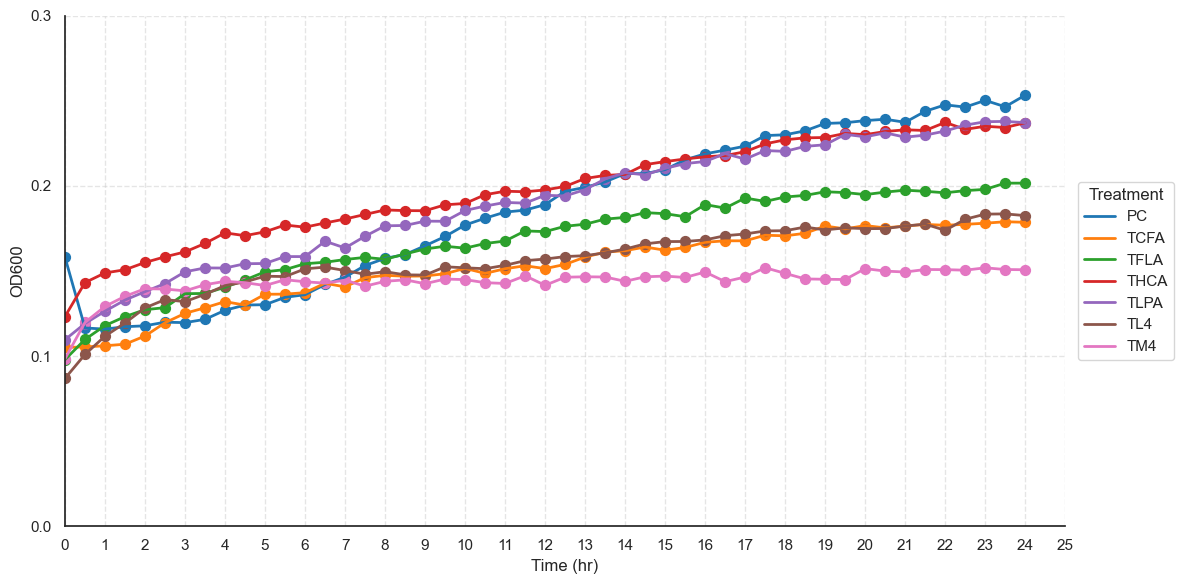

In [154]:
# -----------------------------
# 1. Ensure numeric and clean
# -----------------------------
dg_long["Time"] = pd.to_numeric(dg_long["Time"], errors="coerce")
dg_long["OD600"] = pd.to_numeric(dg_long["OD600"], errors="coerce")
dg_long = dg_long.dropna(subset=["Time", "OD600"])

# -----------------------------
# 3. Plot growth curves (mean only)
# -----------------------------
plt.figure(figsize=(12,6))
ax = plt.gca()

groups = dg_long["Group"].unique()
colors = plt.cm.tab10.colors  # up to 10 colors

for i, group in enumerate(groups):
    sub = dg_long[dg_long["Group"] == group]
    
    # Compute mean OD per time
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    
    # Plot mean line
    ax.plot(times, means.values, label=group, color=colors[i], linewidth=2)
    
    # Plot **dots for mean values only**
    ax.scatter(times, means.values, color=colors[i], s=50)

# -----------------------------
# 5. Customize axes and style
# -----------------------------
x_max = dg_long["Time"].max()+1
y_max = np.ceil(dg_long["OD600"].max() * 10) / 10

ax.set_xlabel("Time (hr)")
ax.set_ylabel("OD600")
ax.set_title("")

ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(np.arange(0, y_max + 0.1, 0.1))

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Place legend outside, left center
ax.legend(title="Treatment", loc='center left', bbox_to_anchor=(1.005, 0.5))

plt.tight_layout()
plt.show()

## RC statistics

In [157]:
# -----------------------
# 1. Load and reshape data
# -----------------------
df = rc_diff

# Melt wide → long format
long_df = df.melt(
    id_vars=["Group"],
    var_name="Time",
    value_name="OD600"
)
long_df["Time"] = long_df["Time"].astype(float)

In [159]:
# df_long['OD'] has all your OD values
stat, p = stats.shapiro(long_df['OD600'])
print("Shapiro-Wilk Test: W =", stat, ", p =", p)

if p > 0.05:
    print("Overall data looks normal")
else:
    print("Overall data is NOT normal")

Shapiro-Wilk Test: W = 0.9629850909464264 , p = 1.6052842143626824e-20
Overall data is NOT normal


In [161]:
# Kruskal-Wallis across all treatments
groups = [long_df[long_df['Group'] == g]['OD600'] for g in long_df['Group'].unique()]
stat, p = stats.kruskal(*groups)
print("Kruskal-Wallis H =", stat, "p =", p)


Kruskal-Wallis H = 94.19455791379376 p = 4.067338794869758e-18


In [163]:
# Run Dunn's test for all groups
posthoc = sp.posthoc_dunn(long_df, val_col='OD600', group_col='Group', p_adjust='bonferroni')

# posthoc is a DataFrame of pairwise p-values
posthoc

,A,B,C,D,E,F,G
A,1.000000e+00,1.502449e-01,5.589935e-17,0.000006,0.000003,0.000171,2.956504e-10
B,1.502449e-01,1.000000e+00,3.329297e-08,0.300557,0.229708,1.000000,9.977964e-04
C,5.589935e-17,3.329297e-08,1.000000e+00,0.007049,0.010114,0.000423,1.000000e+00
D,5.803529e-06,3.005567e-01,7.048812e-03,1.000000,1.000000,1.000000,1.000000e+00
E,3.479289e-06,2.297082e-01,1.011408e-02,1.000000,1.000000,1.000000,1.000000e+00
F,1.707526e-04,1.000000e+00,4.230142e-04,1.000000,1.000000,1.000000,4.559244e-01
G,2.956504e-10,9.977964e-04,1.000000e+00,1.000000,1.000000,0.455924,1.000000e+00


In [165]:
# Define mapping: old label -> new label
group_map = {
    "A": "PC",
    "B": "TCFA",
    "C": "TFLA",
    "D": "THCA",
    "E": "TLPA",
    "F": "TL4",
    "G": "TM4"
}

# Apply mapping to the Group column
long_df["Group"] = long_df["Group"].map(group_map)

In [169]:
# df_long: ['Well','Contain','Group','Time','OD']
control = 'PC'

# Run Dunn's test with Bonferroni correction
posthoc = sp.posthoc_dunn(long_df, val_col='OD600', group_col='Group', p_adjust='bonferroni')

# Build table: Group1 = control, Group2 = other treatments
results = []
for g in posthoc.columns:
    if g != control:
        results.append({
            'Group1': control,
            'Group2': g,
            'p_adj': posthoc.loc[control, g],
            'Significant': posthoc.loc[control, g] < 0.05
        })

results_df = pd.DataFrame(results)
results_df

,Group1,Group2,p_adj,Significant
0,PC,TCFA,1.502449e-01,False
1,PC,TFLA,5.589935e-17,True
2,PC,THCA,5.803529e-06,True
3,PC,TL4,1.707526e-04,True
4,PC,TLPA,3.479289e-06,True
5,PC,TM4,2.956504e-10,True


In [171]:
rc_long = long_df

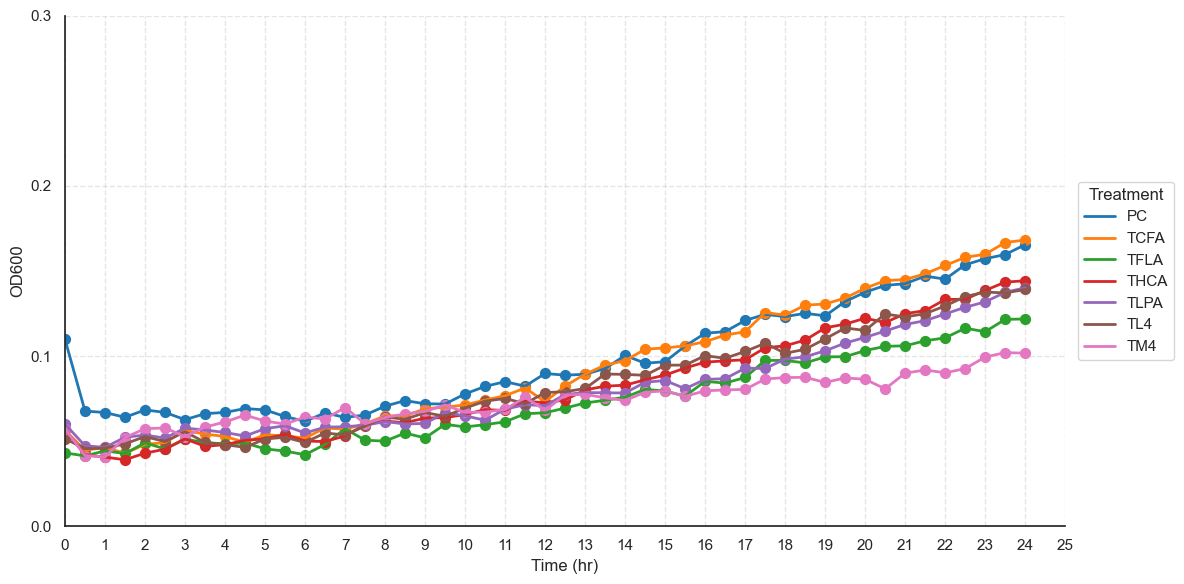

In [173]:
# -----------------------------
# 1. Ensure numeric and clean
# -----------------------------
rc_long["Time"] = pd.to_numeric(rc_long["Time"], errors="coerce")
rc_long["OD600"] = pd.to_numeric(rc_long["OD600"], errors="coerce")
rc_long = rc_long.dropna(subset=["Time", "OD600"])

# -----------------------------
# 3. Plot growth curves (mean only)
# -----------------------------
plt.figure(figsize=(12,6))
ax = plt.gca()

groups = rc_long["Group"].unique()
colors = plt.cm.tab10.colors  # up to 10 colors

for i, group in enumerate(groups):
    sub = rc_long[rc_long["Group"] == group]
    
    # Compute mean OD per time
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    
    # Plot mean line
    ax.plot(times, means.values, label=group, color=colors[i], linewidth=2)
    
    # Plot **dots for mean values only**
    ax.scatter(times, means.values, color=colors[i], s=50)

# -----------------------------
# 5. Customize axes and style
# -----------------------------
x_max = rc_long["Time"].max()+1
y_max = np.ceil(rc_long["OD600"].max() * 10) / 10

ax.set_xlabel("Time (hr)")
ax.set_ylabel("OD600")
ax.set_title("")

ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(np.arange(0, y_max + 0.1, 0.1))

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Place legend outside, left center
ax.legend(title="Treatment", loc='center left', bbox_to_anchor=(1.005, 0.5))

plt.tight_layout()
plt.show()

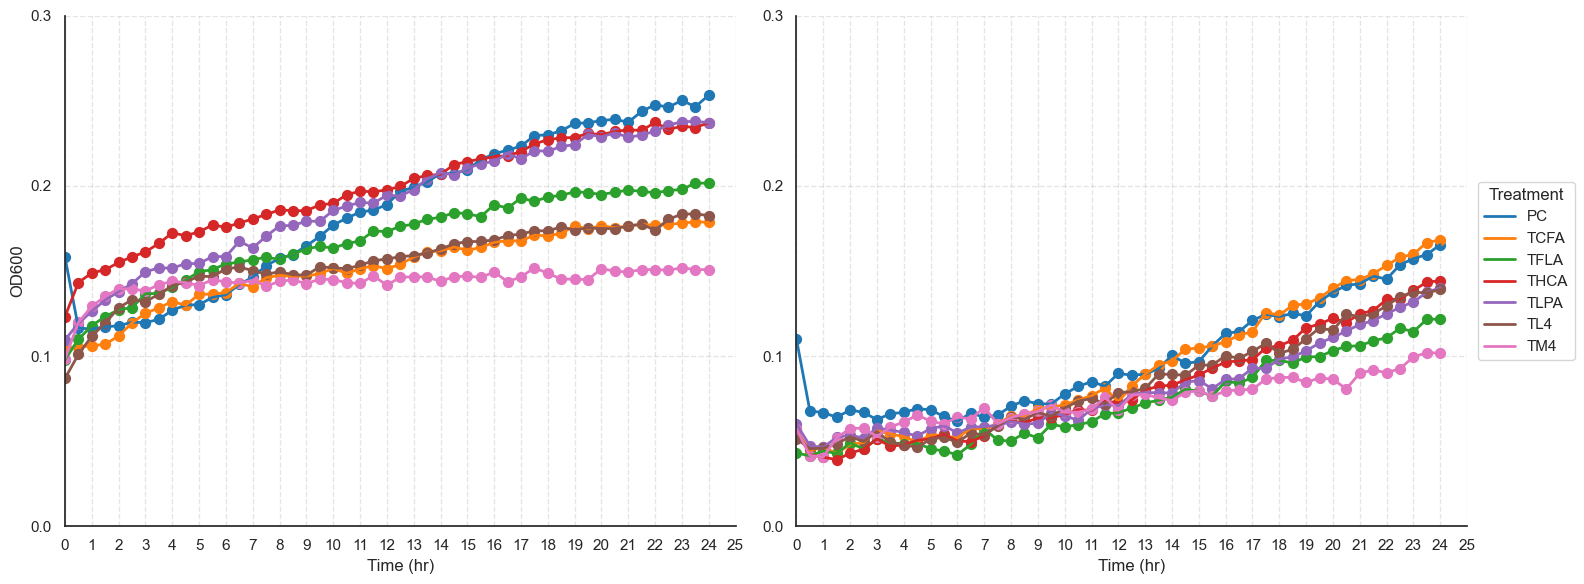

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # removed sharey=True

colors = plt.cm.tab10.colors
x_max = max(dg_long["Time"].max(), rc_long["Time"].max()) + 1
y_max = np.ceil(max(dg_long["OD600"].max(), rc_long["OD600"].max()) * 10) / 10
y_ticks = np.arange(0, y_max + 0.1, 0.1)

# Left subplot
ax = axes[0]
for i, group in enumerate(dg_long["Group"].unique()):
    sub = dg_long[dg_long["Group"] == group]
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    ax.plot(times, means.values, color=colors[i], linewidth=2, label=group)
    ax.scatter(times, means.values, color=colors[i], s=50)

ax.set_xlabel("Time (hr)")
ax.set_ylabel("OD600")
ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(y_ticks)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)

# Right subplot
ax = axes[1]
for i, group in enumerate(rc_long["Group"].unique()):
    sub = rc_long[rc_long["Group"] == group]
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    ax.plot(times, means.values, color=colors[i], linewidth=2, label=group)
    ax.scatter(times, means.values, color=colors[i], s=50)

ax.set_xlabel("Time (hr)")
ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(y_ticks)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)

# Legend only on right subplot
ax.legend(title="Treatment", loc='center left', bbox_to_anchor=(1.005, 0.5))

plt.tight_layout()
plt.show()

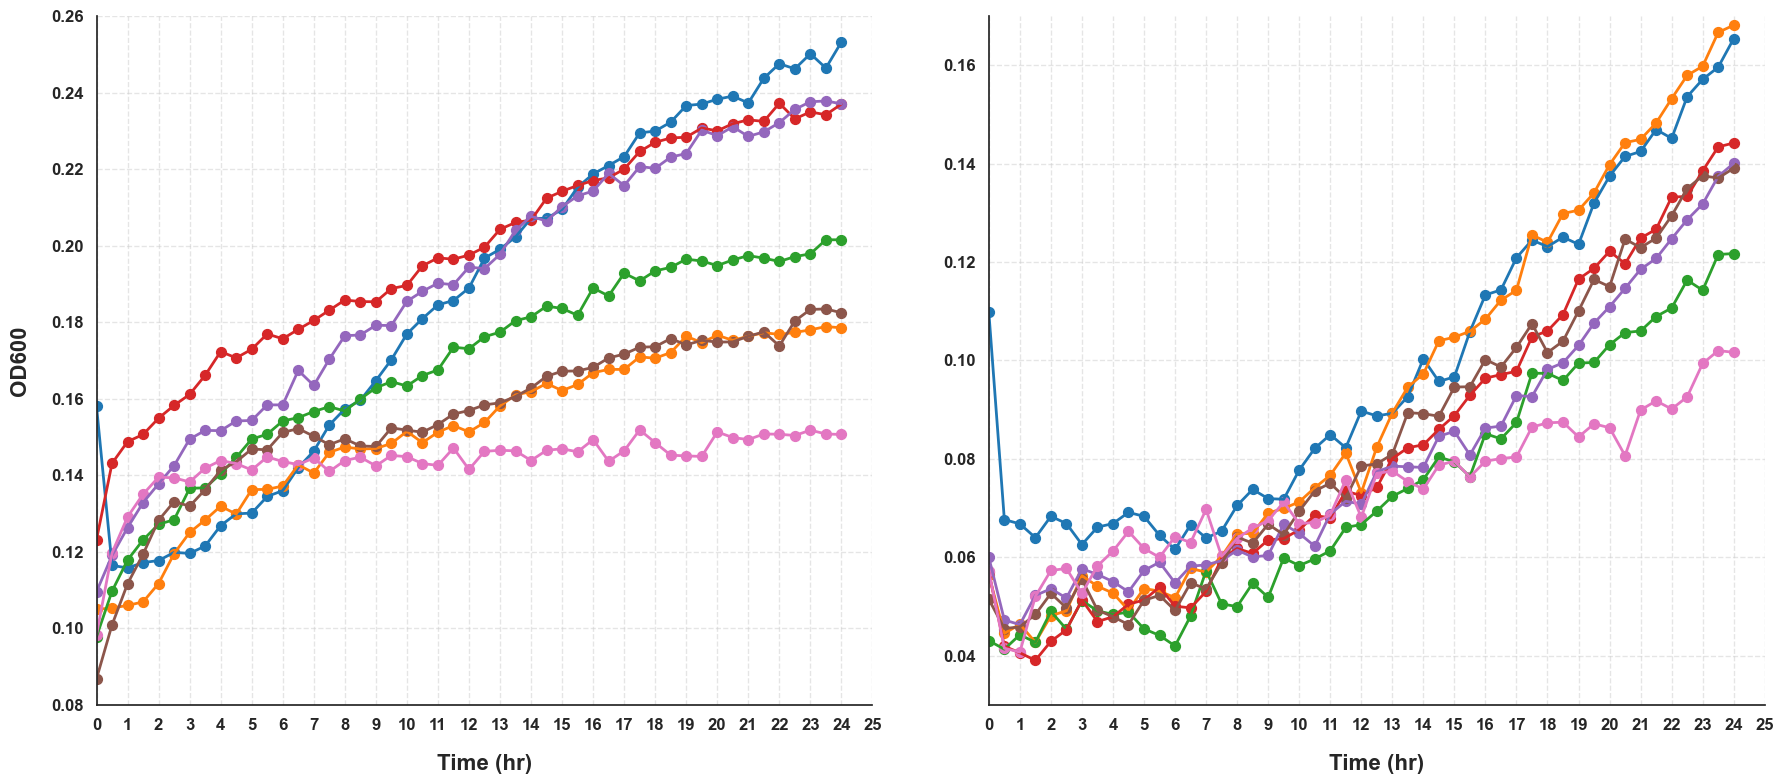

In [177]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # no sharey

colors = plt.cm.tab10.colors
x_max = max(dg_long["Time"].max(), rc_long["Time"].max()) + 1

# -----------------------------
# Left subplot: dg_long
# -----------------------------
ax = axes[0]
for i, group in enumerate(dg_long["Group"].unique()):
    sub = dg_long[dg_long["Group"] == group]
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    ax.plot(times, means.values, color=colors[i], linewidth=2, label=group)
    ax.scatter(times, means.values, color=colors[i], s=50)

ax.set_xlabel("Time (hr)", fontsize=16, fontweight='bold', labelpad = 15)
ax.set_ylabel("OD600", fontsize=16, fontweight='bold', labelpad = 15)
ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(np.arange(0, 0.31, 0.02))  # from 0.1 to 0.3, step 0.05
ax.set_xlim(0, x_max)
ax.set_ylim(0.08, 0.26)

plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax.get_yticklabels(), fontsize=12, fontweight='bold')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title("")

# -----------------------------
# Right subplot: rc_long
# -----------------------------
ax = axes[1]
for i, group in enumerate(rc_long["Group"].unique()):
    sub = rc_long[rc_long["Group"] == group]
    means = sub.groupby("Time")["OD600"].mean()
    times = means.index
    ax.plot(times, means.values, color=colors[i], linewidth=2, label=group)
    ax.scatter(times, means.values, color=colors[i], s=50)

ax.set_xlabel("Time (hr)", fontsize=16, fontweight='bold', labelpad = 15)
ax.set_xticks(np.arange(0, x_max + 1, 1))
ax.set_yticks(np.arange(0, 0.21, 0.02))  # from 0.1 to 0.2, step 0.02
ax.set_xlim(0, x_max)
ax.set_ylim(0.03, 0.17)

plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
plt.setp(ax.get_yticklabels(), fontsize=12, fontweight='bold')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title("")

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.savefig('growthkinetics.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

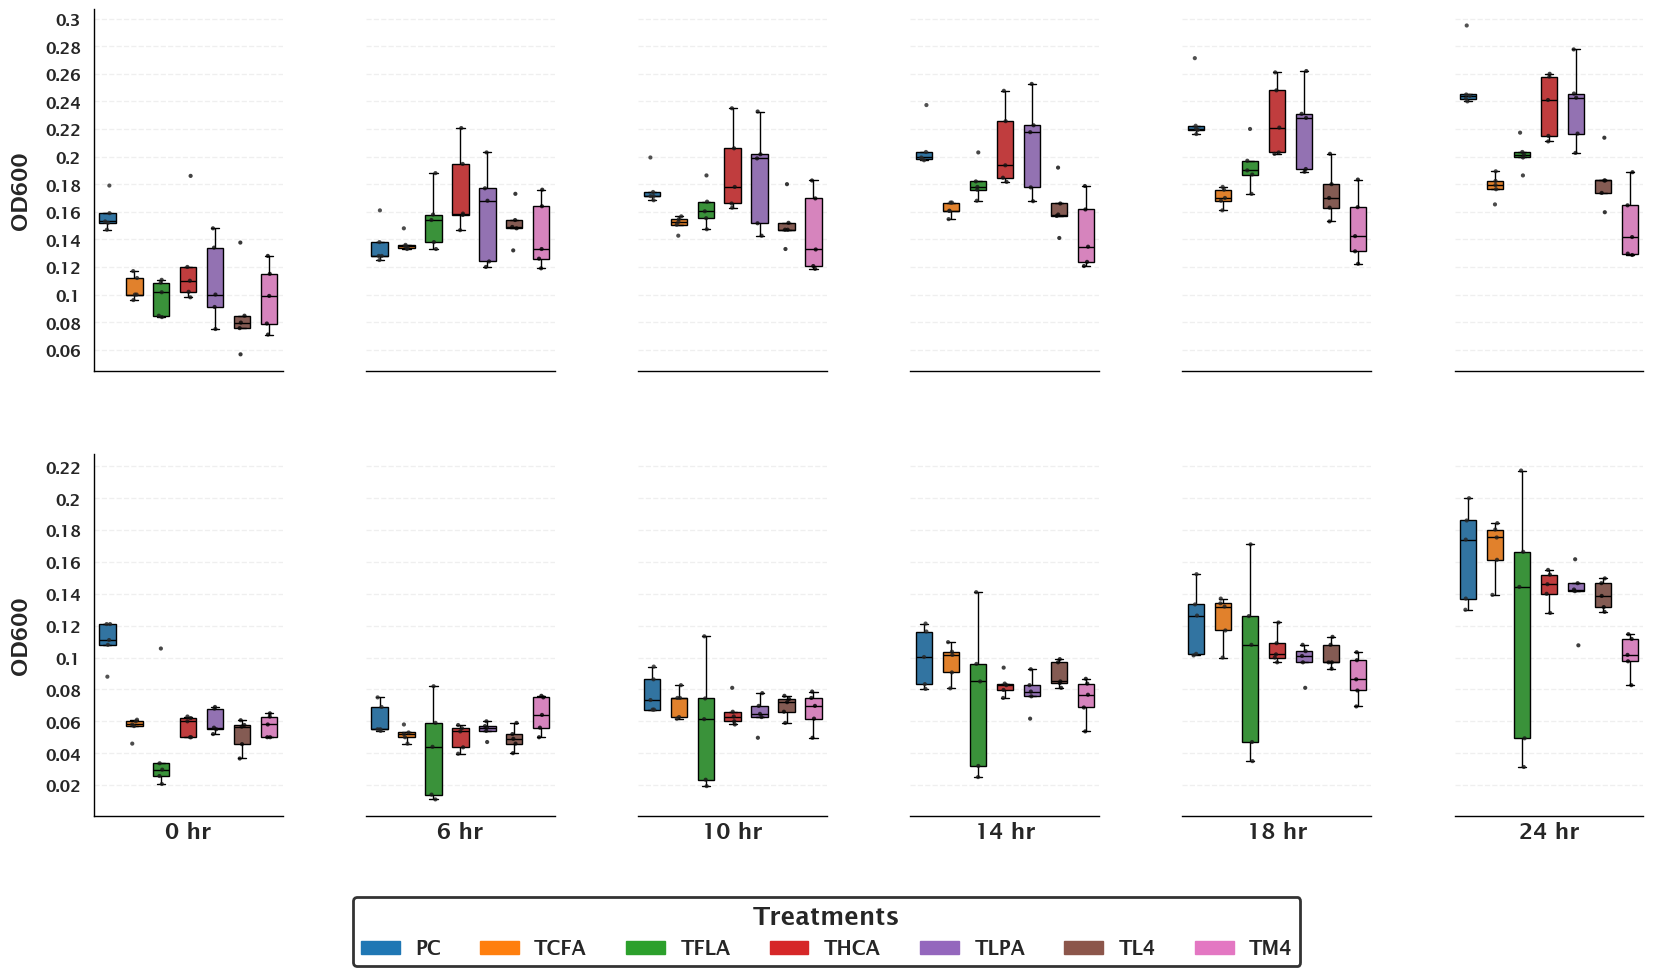

In [261]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

# Time points
time_points = [0, 6, 10, 14, 18, 24]

# Create figure with 2 rows, 6 columns (one column per time point)
fig, axes = plt.subplots(2, len(time_points), figsize=(18, 10), sharey='row')

# --- Top row: dg_long plots ---
df_box1 = dg_long[dg_long['Time'].isin(time_points)]
groups1 = df_box1['Group'].unique()
palette1 = sns.color_palette("tab10", n_colors=len(groups1))

for i, t in enumerate(time_points):
    ax = axes[0, i]
    df_t = df_box1[df_box1['Time'] == t]
    
    sns.boxplot(
        x='Group', y='OD600', data=df_t, hue="Group",
        palette=palette1, fliersize=0, ax=ax, width=0.6, showfliers=True, linewidth=1, boxprops=dict(edgecolor='black'), 
        whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1), medianprops=dict(color='black', linewidth=1)
    )
    
    sns.stripplot(
        x='Group', y='OD600', data=df_t, hue="Group",
        palette='dark:black', size=3, jitter=True, dodge=False, alpha=0.8, ax=ax
    )
    
    # X-axis: group labels removed
    ax.set_xticks([])
    ax.set_xlabel("")
    
    # Y-axis: only first plot has ticks
    if i == 0:
        ax.set_ylabel("OD600",fontweight='bold', fontsize=16, labelpad=10)
        # Explicit y-ticks
        max_y = df_box1['OD600'].max()
        yticks = np.arange(0, np.ceil(max_y*20)/20 + 0.05, 0.02)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontweight='bold', fontsize=12)
        ax.yaxis.set_tick_params(direction='out', length=6)
        ax.spines['left'].set_visible(True)
    else:
        max_y = df_box1['OD600'].max()
        yticks = np.arange(0, np.ceil(max_y*20)/20 + 0.05, 0.01)
        ax.set_ylabel("")
    
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['bottom'].set_color("black")
    ax.spines['left'].set_linewidth(1)
    ax.spines['left'].set_color("black")
    if i != 0:
        sns.despine(ax=ax, left=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# --- Bottom row: rc_long plots ---
df_box2 = rc_long[rc_long['Time'].isin(time_points)]
groups2 = df_box2['Group'].unique()
palette2 = sns.color_palette("tab10", n_colors=len(groups2))

for i, t in enumerate(time_points):
    ax = axes[1, i]
    df_t = df_box2[df_box2['Time'] == t]
    
    sns.boxplot(
        x='Group', y='OD600', data=df_t, hue="Group",
        palette=palette1, fliersize=0, ax=ax, width=0.6, showfliers=True, linewidth=1, boxprops=dict(edgecolor='black'), 
        whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1), medianprops=dict(color='black', linewidth=1)
    )
    
    sns.stripplot(
        x='Group', y='OD600', data=df_t, hue="Group",
        palette='dark:black', size=3, jitter=True, dodge=False, alpha=0.8, ax=ax
    )
    
    # X-axis: group labels removed
    ax.set_xticks([])
    ax.set_xlabel(f"{t} hr", fontweight='bold', fontsize=16)
    
    # Y-axis: only first plot has ticks
    if i == 0:
        ax.set_ylabel("OD600", fontweight='bold', fontsize=16, labelpad=10)
        # Explicit y-ticks
        max_y = df_box2['OD600'].max()
        yticks = np.arange(0, np.ceil(max_y*20)/20 + 0.05, 0.02)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontweight='bold', fontsize=12)
        ax.yaxis.set_tick_params(direction='out', length=6)
        ax.spines['left'].set_visible(True)
    else:
        max_y = df_box2['OD600'].max()
        yticks = np.arange(0, np.ceil(max_y*20)/20 + 0.05, 0.01)
        ax.set_ylabel("")
    
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['bottom'].set_color("black")
    ax.spines['left'].set_linewidth(1)
    ax.spines['left'].set_color("black")
    if i != 0:
        sns.despine(ax=ax, left=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# --- Universal legend at left-center ---
handles = [mpatches.Patch(color=palette1[i], label=groups1[i]) for i in range(len(groups1))]
leg = fig.legend(handles=handles, title="Treatments", bbox_to_anchor=(0.5, -0.05), loc='lower center', title_fontproperties={'size' : 18, 'weight': 'bold'}, 
                 prop={'size': 14, 'weight': 'bold'}, frameon=True, ncol=len(groups))

# Set the outline width
leg.get_frame().set_linewidth(2)  # thickness
leg.get_frame().set_edgecolor('black')  # outline color

plt.tight_layout(pad=5.0)
plt.savefig('growthkinetics_box.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## Statistics at certain time point

### RC

In [183]:
time_points = [0, 6, 10, 14, 18, 24]
alpha = 0.05

overall_list = []
posthoc_list = []

for t in time_points:
    df_t = rc_long[rc_long['Time'] == t]
    groups = df_t['Group'].unique()
    
    if 'Water' not in groups:
        continue  # skip if no Water group
    
    # Overall Kruskal-Wallis
    group_data = [df_t[df_t['Group'] == g]['OD600'].values for g in groups]
    stat, pval = kruskal(*group_data)
    
    overall_list.append({
        'Time': t,
        'Stat': stat,
        'p-value': pval,
        'Significant': pval < alpha
    })
    
    # Post-hoc Dunn's test with Bonferroni
    posthoc = sp.posthoc_dunn(df_t, val_col='OD600', group_col='Group', p_adjust='bonferroni')
    
    # Keep only Water comparisons
    water_comparisons = posthoc.loc['Water', :].drop('Water')
    
    for grp, p in water_comparisons.items():
        posthoc_list.append({
            'Time': t,
            'Group1': 'Water',
            'Group2': grp,
            'p-value': p,
            'Significant': p < alpha
        })

# Convert to DataFrames
overall_df = pd.DataFrame(overall_list)
posthoc_df = pd.DataFrame(posthoc_list)

print(overall_df, '\n')
print(posthoc_df)

Empty DataFrame
Columns: []
Index: [] 

Empty DataFrame
Columns: []
Index: []


### DG

In [186]:
time_points = [0, 6, 10, 14, 18, 24]
alpha = 0.05

overall_list = []
posthoc_list = []

for t in time_points:
    df_t = dg_long[dg_long['Time'] == t]
    groups = df_t['Group'].unique()
    
    if 'Water' not in groups:
        continue  # skip if no Water group
    
    # Overall Kruskal-Wallis
    group_data = [df_t[df_t['Group'] == g]['OD600'].values for g in groups]
    stat, pval = kruskal(*group_data)
    
    overall_list.append({
        'Time': t,
        'Stat': stat,
        'p-value': pval,
        'Significant': pval < alpha
    })
    
    # Post-hoc Dunn's test with Bonferroni
    posthoc = sp.posthoc_dunn(df_t, val_col='OD600', group_col='Group', p_adjust='bonferroni')
    
    # Keep only Water comparisons
    water_comparisons = posthoc.loc['Water', :].drop('Water')
    
    for grp, p in water_comparisons.items():
        posthoc_list.append({
            'Time': t,
            'Group1': 'Water',
            'Group2': grp,
            'p-value': p,
            'Significant': p < alpha
        })

# Convert to DataFrames
overall_df = pd.DataFrame(overall_list)
posthoc_df = pd.DataFrame(posthoc_list)

print(overall_df, '\n')
print(posthoc_df)

Empty DataFrame
Columns: []
Index: [] 

Empty DataFrame
Columns: []
Index: []


# Carbon test

Deinococcus gobienses I-0 strain and Methylobacterium sp. were cultured in 12 wells plate with lignin precursors caffeic acid (TCFA), p-coumaric acid (THCA), ferulic acid (TFLA), L-phenylalanine (TLPA), glucose (TGLU) as sole carbon source in M9 media. The OD was measured at 0, 8, and 24th hr.

In [189]:
#8th hr reading
eig = pd.read_excel('EIGHT.xlsx')
eig

,Treatments,B1,B2,B3,B4,R1,R2,R3,R4
0,NC,0.000,0.000,0.000,0.000,0.191,0.127,0.160,0.164
1,TCFA,0.008,0.009,0.013,0.009,0.217,0.191,0.183,0.185
2,TCH,0.012,0.011,0.011,0.023,0.188,0.178,0.190,0.133
3,TFLA,0.000,0.000,0.000,0.000,0.165,0.155,0.159,0.146
4,THCA,0.000,0.000,0.000,0.000,0.174,0.158,0.165,0.169
5,TLPA,0.000,0.000,0.000,0.000,0.188,0.178,0.181,0.185
6,TGLU,0.000,0.000,0.000,0.000,0.208,0.318,0.195,0.214


In [191]:
eig = eig.T
eig

,0,1,2,3,4,5,6
Treatments,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
B1,0.0,0.008,0.012,0.0,0.0,0.0,0.0
B2,0.0,0.009,0.011,0.0,0.0,0.0,0.0
B3,0.0,0.013,0.011,0.0,0.0,0.0,0.0
B4,0.0,0.009,0.023,0.0,0.0,0.0,0.0
R1,0.191,0.217,0.188,0.165,0.174,0.188,0.208
R2,0.127,0.191,0.178,0.155,0.158,0.178,0.318
R3,0.16,0.183,0.19,0.159,0.165,0.181,0.195
R4,0.164,0.185,0.133,0.146,0.169,0.185,0.214


In [193]:

eig.columns = eig.iloc[0]
eig = eig.iloc[1:]

eig

Treatments,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
B1,0.0,0.008,0.012,0.0,0.0,0.0,0.0
B2,0.0,0.009,0.011,0.0,0.0,0.0,0.0
B3,0.0,0.013,0.011,0.0,0.0,0.0,0.0
B4,0.0,0.009,0.023,0.0,0.0,0.0,0.0
R1,0.191,0.217,0.188,0.165,0.174,0.188,0.208
R2,0.127,0.191,0.178,0.155,0.158,0.178,0.318
R3,0.16,0.183,0.19,0.159,0.165,0.181,0.195
R4,0.164,0.185,0.133,0.146,0.169,0.185,0.214


In [195]:
eig_clean = pd.DataFrame()

# Process columns 1 to 7 (Python index 1 to 7 is df.columns[1:8])
for col in eig.columns[0:8]:
    # Calculate the average of rows 0 to 2 (negative control)
    control_avg = eig[col].iloc[0:4].mean()
    
    # Subtract the control average from rows 3 to 5 (test samples)
    adjusted_values = eig[col].iloc[4:8] - control_avg
    
    # Add the adjusted values to the new DataFrame
    eig_clean[col] = adjusted_values.reset_index(drop=True)

#Print df
eig_clean

,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.191,0.20725,0.17375,0.165,0.174,0.188,0.208
1,0.127,0.18125,0.16375,0.155,0.158,0.178,0.318
2,0.16,0.17325,0.17575,0.159,0.165,0.181,0.195
3,0.164,0.17525,0.11875,0.146,0.169,0.185,0.214


In [197]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in dg_24_clean.columns[0:7]:
    stat, p = shapiro(dg_24_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

PC: W=0.8309, p-value=0.1906
TCFA: W=0.9653, p-value=0.6421
TFLA: W=0.8242, p-value=0.1736
THCA: W=0.9292, p-value=0.4855
TLPA: W=0.9997, p-value=0.9697
TL4: W=0.9542, p-value=0.5883
TM4: W=0.9231, p-value=0.4633


In [199]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in eig_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(eig_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': eig_clean[col].iloc[i]
        })

anova_eig_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_eig_df).fit()
anova_eig = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_eig[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_eig_df['OD'],
    groups=anova_eig_df['Treatment'],
    alpha=0.05
)

print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df         F   p-value  Bonferroni p-value
C(Treatment)  0.017927   6.0  4.188415  0.006354            0.006354
Residual      0.014980  21.0       NaN       NaN                 NaN

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    NC   TCFA   0.0237 0.8631 -0.0376  0.0851  False
    NC    TCH  -0.0025    1.0 -0.0639  0.0589  False
    NC   TFLA  -0.0043    1.0 -0.0656  0.0571  False
    NC   TGLU   0.0733 0.0129  0.0119  0.1346   True
    NC   THCA    0.006 0.9999 -0.0554  0.0674  False
    NC   TLPA   0.0225 0.8897 -0.0389  0.0839  False
  TCFA    TCH  -0.0262  0.801 -0.0876  0.0351  False
  TCFA   TFLA   -0.028 0.7515 -0.0894  0.0334  False
  TCFA   TGLU   0.0495 0.1695 -0.0119  0.1109  False
  TCFA   THCA  -0.0177 0.9613 -0.0791  0.0436  False
  TCFA   TLPA  -0.0013    1.0 -0.062

In [200]:
avg = eig_clean['NC'].mean()
avg

0.1605

In [203]:
for col in eig_clean.columns:
    eig_clean[col] = eig_clean[col] - avg

eig_clean

,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.0305,0.04675,0.01325,0.0045,0.0135,0.0275,0.0475
1,-0.0335,0.02075,0.00325,-0.0055,-0.0025,0.0175,0.1575
2,-0.0005,0.01275,0.01525,-0.0015,0.0045,0.0205,0.0345
3,0.0035,0.01475,-0.04175,-0.0145,0.0085,0.0245,0.0535


In [205]:
eig_clean = eig_clean.drop(columns=['NC'])
eig_clean

,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.04675,0.01325,0.0045,0.0135,0.0275,0.0475
1,0.02075,0.00325,-0.0055,-0.0025,0.0175,0.1575
2,0.01275,0.01525,-0.0015,0.0045,0.0205,0.0345
3,0.01475,-0.04175,-0.0145,0.0085,0.0245,0.0535


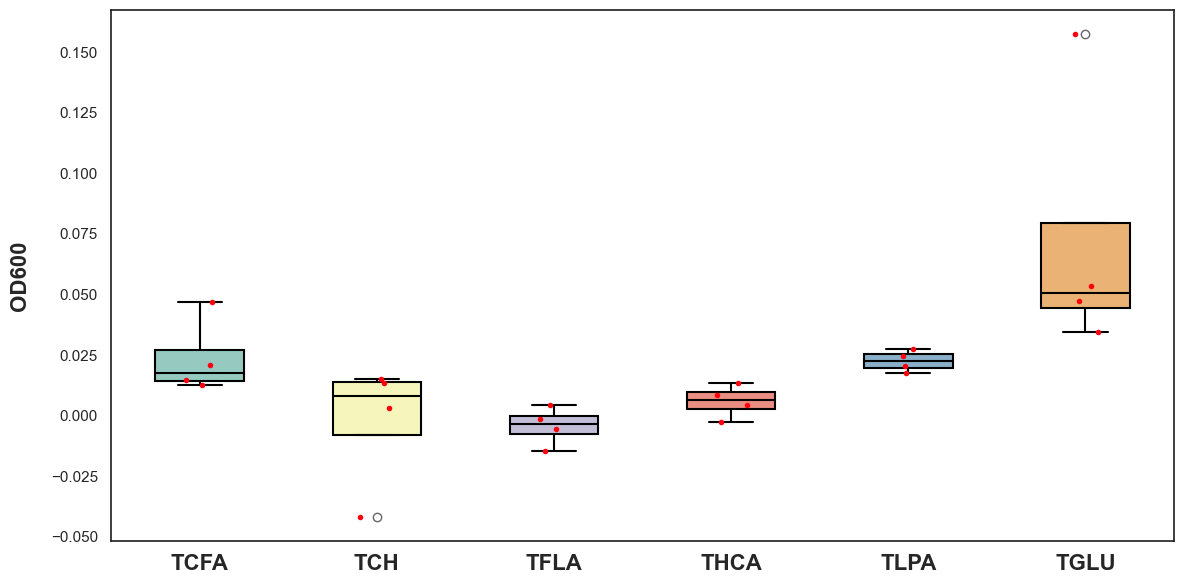

In [207]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

sns.set(style="white")
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=eig_clean, 
                 palette="Set3", 
                 showfliers=True, 
                 width=0.5, 
                 linewidth=1.5,
                 boxprops=dict(edgecolor='black'),       # box outline
                 whiskerprops=dict(color='black', linewidth=1.5),  # whiskers
                 capprops=dict(color='black', linewidth=1.5),      # caps
                 medianprops=dict(color='black', linewidth=1.5)    # median line
)
sns.stripplot(data=eig_clean, color = "#ff000d", size = 4, jitter = True)
plt.xticks(fontweight='bold', fontsize=16)
plt.ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
plt.tight_layout()
plt.savefig('eight_clean.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## 24th hr

In [209]:
#24th hr reading
tf = pd.read_excel('TWENTY_FOUR.xlsx')
tf

,Treatments,B1,B2,B3,B4,R1,R2,R3,R4
0,NC,0.000,0.000,0.000,0.000,0.306,0.303,0.284,0.238
1,TCFA,0.056,0.056,0.057,0.057,0.388,0.283,0.339,0.349
2,TCH,0.083,0.087,0.082,0.099,0.441,0.429,0.443,0.454
3,TFLA,0.000,0.000,0.000,0.000,0.236,0.233,0.200,0.180
4,THCA,0.000,0.000,0.000,0.000,0.252,0.304,0.291,0.323
5,TLPA,0.001,0.004,0.000,0.005,0.335,0.322,0.315,0.304
6,TGLU,0.000,0.000,0.000,0.000,0.265,0.280,0.245,0.269


In [210]:
tf = tf.T
tf

,0,1,2,3,4,5,6
Treatments,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
B1,0.0,0.056,0.083,0.0,0.0,0.001,0.0
B2,0.0,0.056,0.087,0.0,0.0,0.004,0.0
B3,0.0,0.057,0.082,0.0,0.0,0.0,0.0
B4,0.0,0.057,0.099,0.0,0.0,0.005,0.0
R1,0.306,0.388,0.441,0.236,0.252,0.335,0.265
R2,0.303,0.283,0.429,0.233,0.304,0.322,0.28
R3,0.284,0.339,0.443,0.2,0.291,0.315,0.245
R4,0.238,0.349,0.454,0.18,0.323,0.304,0.269


In [211]:

tf.columns = tf.iloc[0]
tf = tf.iloc[1:]

tf

Treatments,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
B1,0.0,0.056,0.083,0.0,0.0,0.001,0.0
B2,0.0,0.056,0.087,0.0,0.0,0.004,0.0
B3,0.0,0.057,0.082,0.0,0.0,0.0,0.0
B4,0.0,0.057,0.099,0.0,0.0,0.005,0.0
R1,0.306,0.388,0.441,0.236,0.252,0.335,0.265
R2,0.303,0.283,0.429,0.233,0.304,0.322,0.28
R3,0.284,0.339,0.443,0.2,0.291,0.315,0.245
R4,0.238,0.349,0.454,0.18,0.323,0.304,0.269


In [216]:
tf_clean = pd.DataFrame()

# Process columns 1 to 7 (Python index 1 to 7 is df.columns[1:8])
for col in tf.columns[0:8]:
    # Calculate the average of rows 0 to 2 (negative control)
    control_avg = tf[col].iloc[0:4].mean()
    
    # Subtract the control average from rows 3 to 5 (test samples)
    adjusted_values = tf[col].iloc[4:8] - control_avg
    
    # Add the adjusted values to the new DataFrame
    tf_clean[col] = adjusted_values.reset_index(drop=True)

#Print df
tf_clean

,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.306,0.3315,0.35325,0.236,0.252,0.3325,0.265
1,0.303,0.2265,0.34125,0.233,0.304,0.3195,0.28
2,0.284,0.2825,0.35525,0.2,0.291,0.3125,0.245
3,0.238,0.2925,0.36625,0.18,0.323,0.3015,0.269


In [217]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in tf_clean.columns[0:7]:
    stat, p = shapiro(tf_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

NC: W=0.8425, p-value=0.2029
TCFA: W=0.9673, p-value=0.8245
TCH: W=0.9746, p-value=0.8696
TFLA: W=0.8852, p-value=0.3612
THCA: W=0.9600, p-value=0.7788
TLPA: W=0.9978, p-value=0.9929
TGLU: W=0.9537, p-value=0.7390


In [220]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in tf_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(tf_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': tf_clean[col].iloc[i]
        })

anova_tf_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_tf_df).fit()
anova_tf = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_tf[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_tf_df['OD'],
    groups=anova_tf_df['Treatment'],
    alpha=0.05
)

print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df          F   p-value  Bonferroni p-value
C(Treatment)  0.046012   6.0  10.778676  0.000017            0.000017
Residual      0.014941  21.0        NaN       NaN                 NaN

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    NC   TCFA   0.0005    1.0 -0.0608  0.0618  False
    NC    TCH   0.0712 0.0161  0.0099  0.1326   True
    NC   TFLA  -0.0705 0.0176 -0.1318 -0.0092   True
    NC   TGLU   -0.018 0.9584 -0.0793  0.0433  False
    NC   THCA   0.0097 0.9983 -0.0516  0.0711  False
    NC   TLPA   0.0338 0.5686 -0.0276  0.0951  False
  TCFA    TCH   0.0707 0.0171  0.0094  0.1321   True
  TCFA   TFLA   -0.071 0.0166 -0.1323 -0.0097   True
  TCFA   TGLU  -0.0185 0.9528 -0.0798  0.0428  False
  TCFA   THCA   0.0092 0.9987 -0.0521  0.0706  False
  TCFA   TLPA   0.0332 0.5849 -0.

In [221]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in tf_clean.columns[0:7]:
    stat, p = shapiro(tf_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

NC: W=0.8425, p-value=0.2029
TCFA: W=0.9673, p-value=0.8245
TCH: W=0.9746, p-value=0.8696
TFLA: W=0.8852, p-value=0.3612
THCA: W=0.9600, p-value=0.7788
TLPA: W=0.9978, p-value=0.9929
TGLU: W=0.9537, p-value=0.7390


In [222]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in tf_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(tf_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': tf_clean[col].iloc[i]
        })

anova_tf_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_tf_df).fit()
anova_tf = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_tf[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_tf_df['OD'],
    groups=anova_tf_df['Treatment'],
    alpha=0.05
)

print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df          F   p-value  Bonferroni p-value
C(Treatment)  0.046012   6.0  10.778676  0.000017            0.000017
Residual      0.014941  21.0        NaN       NaN                 NaN

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    NC   TCFA   0.0005    1.0 -0.0608  0.0618  False
    NC    TCH   0.0712 0.0161  0.0099  0.1326   True
    NC   TFLA  -0.0705 0.0176 -0.1318 -0.0092   True
    NC   TGLU   -0.018 0.9584 -0.0793  0.0433  False
    NC   THCA   0.0097 0.9983 -0.0516  0.0711  False
    NC   TLPA   0.0338 0.5686 -0.0276  0.0951  False
  TCFA    TCH   0.0707 0.0171  0.0094  0.1321   True
  TCFA   TFLA   -0.071 0.0166 -0.1323 -0.0097   True
  TCFA   TGLU  -0.0185 0.9528 -0.0798  0.0428  False
  TCFA   THCA   0.0092 0.9987 -0.0521  0.0706  False
  TCFA   TLPA   0.0332 0.5849 -0.

In [225]:
avg = tf_clean['NC'].mean()
avg

0.28275

In [226]:
for col in tf_clean.columns:
    tf_clean[col] = tf_clean[col] - avg

tf_clean

,NC,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.02325,0.04875,0.0705,-0.04675,-0.03075,0.04975,-0.01775
1,0.02025,-0.05625,0.0585,-0.04975,0.02125,0.03675,-0.00275
2,0.00125,-0.00025,0.0725,-0.08275,0.00825,0.02975,-0.03775
3,-0.04475,0.00975,0.0835,-0.10275,0.04025,0.01875,-0.01375


In [228]:
tf_clean = tf_clean.drop(columns=['NC'])
tf_clean

,TCFA,TCH,TFLA,THCA,TLPA,TGLU
0,0.04875,0.0705,-0.04675,-0.03075,0.04975,-0.01775
1,-0.05625,0.0585,-0.04975,0.02125,0.03675,-0.00275
2,-0.00025,0.0725,-0.08275,0.00825,0.02975,-0.03775
3,0.00975,0.0835,-0.10275,0.04025,0.01875,-0.01375


In [232]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in tf_clean.columns[0:7]:
    stat, p = shapiro(tf_clean[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}")

TCFA: W=0.9673, p-value=0.8245
TCH: W=0.9746, p-value=0.8696
TFLA: W=0.8852, p-value=0.3612
THCA: W=0.9600, p-value=0.7788
TLPA: W=0.9978, p-value=0.9929
TGLU: W=0.9537, p-value=0.7390


In [234]:
# One way ANOVA testing
# Prepare data for one-way ANOVA
data = []
for col in tf_clean.columns[0:7]:  # treatments are columns 1–7
    for i in range(len(tf_clean)):  # use all rows (3 replicates)
        data.append({
            'Treatment': col,
            'OD': tf_clean[col].iloc[i]
        })

anova_tf_df = pd.DataFrame(data)

# One-way ANOVA
model = ols('OD ~ C(Treatment)', data=anova_tf_df).fit()
anova_tf = sm.stats.anova_lm(model, typ=2)

# Bonferroni correction
anova_table = anova_tf[['sum_sq', 'df', 'F', 'PR(>F)']].rename(columns={'PR(>F)': 'p-value'})
mask = anova_table['p-value'].notna()
_, corrected_p_values, _, _ = multipletests(anova_table.loc[mask, 'p-value'], method='bonferroni')
anova_table['Bonferroni p-value'] = np.nan
anova_table.loc[mask, 'Bonferroni p-value'] = corrected_p_values

print("\nOne-way ANOVA with Bonferroni correction:")
print(anova_table)

# Tukey HSD for all treatments
tukey_all = pairwise_tukeyhsd(
    endog=anova_tf_df['OD'],
    groups=anova_tf_df['Treatment'],
    alpha=0.05
)

print("\nAll Tukey HSD Results:\n", tukey_all)


One-way ANOVA with Bonferroni correction:
                sum_sq    df          F   p-value  Bonferroni p-value
C(Treatment)  0.045944   5.0  13.799212  0.000013            0.000013
Residual      0.011986  18.0        NaN       NaN                 NaN

All Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  TCFA    TCH   0.0708 0.0119  0.0128  0.1287   True
  TCFA   TFLA   -0.071 0.0116  -0.129  -0.013   True
  TCFA   TGLU  -0.0185 0.9073 -0.0765  0.0395  False
  TCFA   THCA   0.0092 0.9952 -0.0487  0.0672  False
  TCFA   TLPA   0.0332  0.477 -0.0247  0.0912  False
   TCH   TFLA  -0.1418    0.0 -0.1997 -0.0838   True
   TCH   TGLU  -0.0892 0.0014 -0.1472 -0.0313   True
   TCH   THCA  -0.0615  0.034 -0.1195 -0.0035   True
   TCH   TLPA  -0.0375  0.352 -0.0955  0.0205  False
  TFLA   TGLU   0.0525 0.0893 -0.0055  0.1105  False
  TFLA   THCA   0.0802  0.004  0.

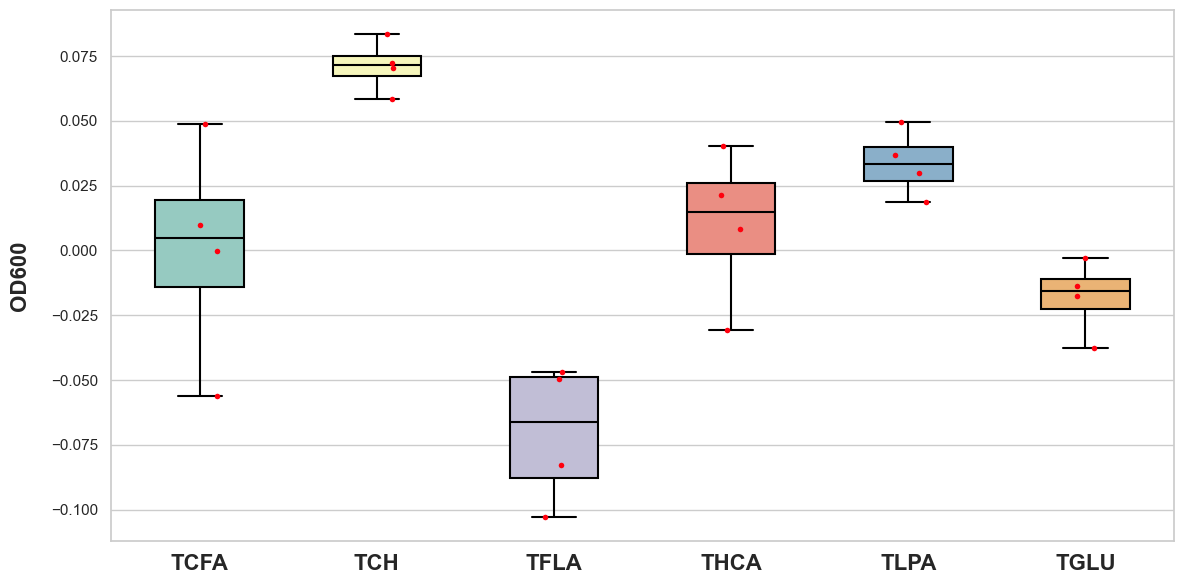

In [235]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=tf_clean, 
                 palette="Set3", 
                 showfliers=True, 
                 width=0.5, 
                 linewidth=1.5,
                 boxprops=dict(edgecolor='black'),       # box outline
                 whiskerprops=dict(color='black', linewidth=1.5),  # whiskers
                 capprops=dict(color='black', linewidth=1.5),      # caps
                 medianprops=dict(color='black', linewidth=1.5)    # median line
)
sns.stripplot(data=tf_clean, color = "#ff000d", size = 4, jitter = True)
plt.xticks(fontweight='bold', fontsize=16)
plt.ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
plt.tight_layout()
plt.savefig('twenty_four_clean.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Combined plot

C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_14296\3899002882.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold', fontsize=12)
C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_14296\3899002882.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), fontweight='bold', fontsize=12)


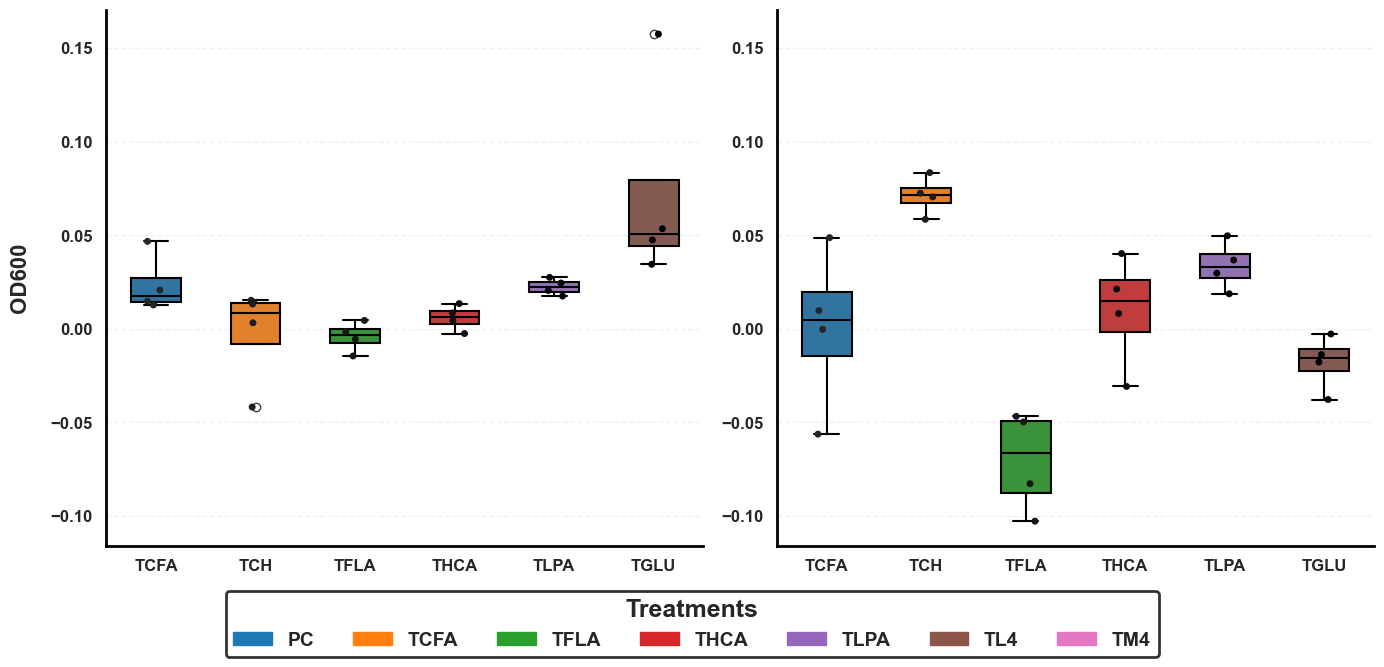

In [274]:
# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'

# Set seaborn style
sns.set(style="whitegrid")

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# First subplot: rc_24_clean
sns.boxplot(data=eig_clean,
            palette="tab10", 
            showfliers=True, 
            width=0.5, 
            linewidth=1.5,
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5),
            ax=axes[0]
)
sns.stripplot(data=eig_clean, palette="dark:black", size=5, jitter=True, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold', fontsize=12)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
axes[0].set_ylabel("OD600", fontweight='bold', fontsize=16, labelpad=15)
axes[0].set_xlabel("")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(True)
axes[0].spines['bottom'].set_visible(True)
axes[0].spines['bottom'].set_linewidth(2)
axes[0].spines['bottom'].set_color("black")
axes[0].spines['left'].set_linewidth(2)
axes[0].spines['left'].set_color("black")
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Second subplot: dg_24_clean
sns.boxplot(data=tf_clean,
            palette="tab10", 
            showfliers=True, 
            width=0.5, 
            linewidth=1.5,
            boxprops=dict(edgecolor='black'),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=1.5),
            ax=axes[1]
)
sns.stripplot(data=tf_clean, palette="dark:black", size=5, jitter=True, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontweight='bold', fontsize=12)
axes[1].tick_params(axis='y', which='both', labelleft=True)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # No ylabel for second plot
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)
axes[1].spines['bottom'].set_linewidth(2)
axes[1].spines['bottom'].set_color("black")
axes[1].spines['left'].set_linewidth(2)
axes[1].spines['left'].set_color("black")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- Universal legend at left-center ---
handles = [mpatches.Patch(color=palette1[i], label=groups1[i]) for i in range(len(groups1))]
leg = fig.legend(handles=handles, title="Treatments", bbox_to_anchor=(0.5, -0.125), loc='lower center', title_fontproperties={'size' : 18, 'weight': 'bold'}, 
                 prop={'size': 14, 'weight': 'bold'}, frameon=True, ncol=len(groups))

# Set the outline width
leg.get_frame().set_linewidth(2)  # thickness
leg.get_frame().set_edgecolor('black')  # outline color

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('carbon.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# GC Readings

The Teqing, IR64, and Jasmine 85 rice cultivars of indica sub-species, and Cypress, La Grue, and Bengal rice cultivar of japonica sub-species was taken for testing the net carbon monoxide (CO) metabolism by it leaf and its leaf microbiome. The leaf samples was carefully taken in glass bottles and 100 ppm of CO was injected and sealed. The leaves were treated with caffeic acid and just with water to find the effect of caffeci acid on leaf microbiome in CO metabolism. The gas-chromatography (GC) reading were measured at 0, 24, 48, 72, and 168th hr. The CO metabolism tread of each cultivar were assessed below.

In [31]:
lf = pd.read_csv('GC-leaf.csv')
lf

,Hours,Ct-H-1,Ct-H-2,Ct-H-3,Ct-C-1,Ct-C-2,Ct-C-3,St-10,St-40,TEQ-H,...,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C
0,0,66.2,62.2,62.5,62.6,66.2,62.7,2.8,13.8,60.5,...,59.3,57.1,57.3,55.3,61.70,60.40,57.5,58.2,58.3,57.3
1,24,54.5,54.9,54.8,54.5,54.3,54.1,2.8,12.6,45.6,...,42.6,45.2,48.1,47.5,30.26,32.15,30.2,33.2,47.7,50.9
2,48,59.1,59.9,58.9,60.0,59.7,58.6,3.0,12.7,44.9,...,46.9,43.1,49.0,46.8,32.70,23.90,18.6,22.9,56.5,48.5
3,72,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,47.3,...,46.4,33.7,37.6,40.1,20.90,11.20,11.8,8.9,43.4,42.7
4,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,...,56.1,14.5,13.7,20.9,5.40,14.00,3.6,2.5,27.7,19.6


In [33]:
lf.iloc[4, 1:9] = lf.iloc[3, 1:9]
lf

,Hours,Ct-H-1,Ct-H-2,Ct-H-3,Ct-C-1,Ct-C-2,Ct-C-3,St-10,St-40,TEQ-H,...,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C
0,0,66.2,62.2,62.5,62.6,66.2,62.7,2.8,13.8,60.5,...,59.3,57.1,57.3,55.3,61.70,60.40,57.5,58.2,58.3,57.3
1,24,54.5,54.9,54.8,54.5,54.3,54.1,2.8,12.6,45.6,...,42.6,45.2,48.1,47.5,30.26,32.15,30.2,33.2,47.7,50.9
2,48,59.1,59.9,58.9,60.0,59.7,58.6,3.0,12.7,44.9,...,46.9,43.1,49.0,46.8,32.70,23.90,18.6,22.9,56.5,48.5
3,72,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,47.3,...,46.4,33.7,37.6,40.1,20.90,11.20,11.8,8.9,43.4,42.7
4,168,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,22.0,...,56.1,14.5,13.7,20.9,5.40,14.00,3.6,2.5,27.7,19.6


In [35]:
ct = pd.DataFrame()
ct['Hours'] = lf['Hours']
ct[['Ct-H-1', 'Ct-H-2', 'Ct-H-3']] = lf[['Ct-H-1', 'Ct-H-2', 'Ct-H-3']]
ct[['Ct-C-1', 'Ct-C-2', 'Ct-C-3']] = lf[['Ct-C-1', 'Ct-C-2', 'Ct-C-3']]
ct

,Hours,Ct-H-1,Ct-H-2,Ct-H-3,Ct-C-1,Ct-C-2,Ct-C-3
0,0,66.2,62.2,62.5,62.6,66.2,62.7
1,24,54.5,54.9,54.8,54.5,54.3,54.1
2,48,59.1,59.9,58.9,60.0,59.7,58.6
3,72,55.3,53.9,57.8,51.7,53.3,51.8
4,168,55.3,53.9,57.8,51.7,53.3,51.8


In [37]:
lf['Ct'] = lf[['Ct-H-1', 'Ct-H-2', 'Ct-H-3', 'Ct-C-1', 'Ct-C-2', 'Ct-C-3']].mean(axis=1)
lf

,Hours,Ct-H-1,Ct-H-2,Ct-H-3,Ct-C-1,Ct-C-2,Ct-C-3,St-10,St-40,TEQ-H,...,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C,Ct
0,0,66.2,62.2,62.5,62.6,66.2,62.7,2.8,13.8,60.5,...,57.1,57.3,55.3,61.70,60.40,57.5,58.2,58.3,57.3,63.733333
1,24,54.5,54.9,54.8,54.5,54.3,54.1,2.8,12.6,45.6,...,45.2,48.1,47.5,30.26,32.15,30.2,33.2,47.7,50.9,54.516667
2,48,59.1,59.9,58.9,60.0,59.7,58.6,3.0,12.7,44.9,...,43.1,49.0,46.8,32.70,23.90,18.6,22.9,56.5,48.5,59.366667
3,72,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,47.3,...,33.7,37.6,40.1,20.90,11.20,11.8,8.9,43.4,42.7,53.966667
4,168,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,22.0,...,14.5,13.7,20.9,5.40,14.00,3.6,2.5,27.7,19.6,53.966667


In [39]:
from sklearn.linear_model import LinearRegression

In [41]:
sl = lf[['Hours', 'St-10', 'St-40', 'Ct']]
sl

,Hours,St-10,St-40,Ct
0,0,2.8,13.8,63.733333
1,24,2.8,12.6,54.516667
2,48,3.0,12.7,59.366667
3,72,3.5,12.2,53.966667
4,168,3.5,12.2,53.966667


In [43]:
concentration = np.array([10, 40, 100])

x_vals = np.array([10, 40, 100]).reshape(-1, 1)

def calc_regression(row):
    y_vals = np.array([row['St-10'], row['St-40'], row['Ct']])
    model = LinearRegression().fit(x_vals, y_vals)
    return pd.Series({'slope': model.coef_[0], 'intercept': model.intercept_})

lf[['slope', 'intercept']] = sl.apply(calc_regression, axis = 1)
lf

,Hours,Ct-H-1,Ct-H-2,Ct-H-3,Ct-C-1,Ct-C-2,Ct-C-3,St-10,St-40,TEQ-H,...,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C,Ct,slope,intercept
0,0,66.2,62.2,62.5,62.6,66.2,62.7,2.8,13.8,60.5,...,55.3,61.70,60.40,57.5,58.2,58.3,57.3,63.733333,0.699206,-8.182540
1,24,54.5,54.9,54.8,54.5,54.3,54.1,2.8,12.6,45.6,...,47.5,30.26,32.15,30.2,33.2,47.7,50.9,54.516667,0.592341,-6.311508
2,48,59.1,59.9,58.9,60.0,59.7,58.6,3.0,12.7,44.9,...,46.8,32.70,23.90,18.6,22.9,56.5,48.5,59.366667,0.647937,-7.374603
3,72,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,47.3,...,40.1,20.90,11.20,11.8,8.9,43.4,42.7,53.966667,0.580079,-5.781746
4,168,55.3,53.9,57.8,51.7,53.3,51.8,3.5,12.2,22.0,...,20.9,5.40,14.00,3.6,2.5,27.7,19.6,53.966667,0.580079,-5.781746


In [45]:
cols = ['TEQ-H', 'TEQ-C', 'IR64-H', 'IR64-C', 'J85-H', 'J85-C', 'Cyp-H', 'Cyp-C', 'LG-H', 'LG-C', 'Ben-H', 'Ben-C']

conc = lf[cols].subtract(lf['intercept'], axis = 0).divide(lf['slope'], axis = 0)
conc

,TEQ-H,TEQ-C,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C
0,98.229285,93.938706,96.513053,93.366629,93.652667,90.792281,99.945516,98.086266,93.938706,94.939841,95.082860,93.652667
1,87.637837,87.806659,82.573190,86.962551,91.858377,90.845448,61.740604,64.931332,61.639311,66.703959,91.183091,96.585382
2,80.678589,80.524253,83.765311,77.900539,87.006369,83.610975,61.849584,48.268006,40.088192,46.724645,98.581578,86.234689
3,91.507730,83.750171,89.956218,68.062662,74.785880,79.095636,45.996716,29.274867,30.309208,25.309892,84.784512,83.577781
4,47.893009,88.059926,106.678068,34.963743,33.584622,45.996716,19.276235,34.101792,16.173211,14.276919,57.719250,43.755644


In [47]:
conc['Hours'] = lf['Hours']
conc

,TEQ-H,TEQ-C,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C,Hours
0,98.229285,93.938706,96.513053,93.366629,93.652667,90.792281,99.945516,98.086266,93.938706,94.939841,95.082860,93.652667,0
1,87.637837,87.806659,82.573190,86.962551,91.858377,90.845448,61.740604,64.931332,61.639311,66.703959,91.183091,96.585382,24
2,80.678589,80.524253,83.765311,77.900539,87.006369,83.610975,61.849584,48.268006,40.088192,46.724645,98.581578,86.234689,48
3,91.507730,83.750171,89.956218,68.062662,74.785880,79.095636,45.996716,29.274867,30.309208,25.309892,84.784512,83.577781,72
4,47.893009,88.059926,106.678068,34.963743,33.584622,45.996716,19.276235,34.101792,16.173211,14.276919,57.719250,43.755644,168


In [49]:
conc.to_csv('CO_concentrations.csv', index = False)

In [53]:
# Normality testing with Shapiro
# Dictionary to store results
results = {}

# Loop through columns index
for col in conc.columns[0:13]:
    stat, p = shapiro(conc[col])
    results[col] = {'W-statistic': stat, 'p-value': p}

# Print nicely
for col, res in results.items():
    print(f"{col}: W={res['W-statistic']:.4f}, p-value={res['p-value']:.4f}, Normal={res['p-value'] < 0.05}")

TEQ-H: W=0.8408, p-value=0.1671, Normal=False
TEQ-C: W=0.9694, p-value=0.8716, Normal=False
IR64-H: W=0.9196, p-value=0.5274, Normal=False
IR64-C: W=0.8952, p-value=0.3837, Normal=False
J85-H: W=0.7808, p-value=0.0560, Normal=False
J85-C: W=0.7685, p-value=0.0438, Normal=True
Cyp-H: W=0.9615, p-value=0.8187, Normal=False
Cyp-C: W=0.9125, p-value=0.4826, Normal=False
LG-H: W=0.9529, p-value=0.7576, Normal=False
LG-C: W=0.9645, p-value=0.8388, Normal=False
Ben-H: W=0.8232, p-value=0.1235, Normal=False
Ben-C: W=0.7728, p-value=0.0478, Normal=True
Hours: W=0.9031, p-value=0.4272, Normal=False


In [493]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

def get_pvalues_summary(df, x_col, pairs, timepoints=None):
    """
    Compute per-pair significance, trend comparison, and overall ANOVA for multiple pairs.
    Applies Bonferroni correction to per-pair p-values.

    Parameters:
        df (pd.DataFrame): dataframe containing time column and measurement columns
        x_col (str): name of time column
        pairs (list of tuples): list of (treated, untreated) pairs
        timepoints (list, optional): subset of timepoints to consider

    Returns:
        per_pair_df (pd.DataFrame): table of per-pair p-values and trend comparisons
        anova_all (pd.DataFrame): overall ANOVA table across all pairs
    """

    if timepoints is not None:
        df = df.loc[timepoints]

    results = []
    x = df[x_col].values.astype(float)

    # --- Per-pair analysis ---
    for y1, y2 in pairs:
        y_untreated = df[y1].values.astype(float)
        y_treated = df[y2].values.astype(float)

        # Individual slopes (linear regression)
        _, _, _, p_untreated, _ = linregress(x, y_untreated)
        _, _, _, p_treated, _ = linregress(x, y_treated)

        # Trend comparison (interaction p-value)
        temp_df = pd.DataFrame({
            x_col: list(x) * 2,
            "Value": list(y_untreated) + list(y_treated),
            "Group": [y1] * len(x) + [y2] * len(x)
        })
        model = ols("Value ~ " + x_col + " * Group", data=temp_df).fit()
        anova_res = sm.stats.anova_lm(model, typ=2)
        p_trend = anova_res.loc[f"{x_col}:Group", "PR(>F)"]

        results.append({
            "Pair": f"{y1} vs {y2}",
            "Untreated Sig": p_untreated,
            "Treated Sig": p_treated,
            "Trend Comparison": p_trend
        })

    per_pair_df = pd.DataFrame(results)

    # --- Apply Bonferroni correction ---
    for col in ['Untreated Sig', 'Treated Sig', 'Trend Comparison']:
        pvals = per_pair_df[col].values
        fdr_corrected = multipletests(pvals, alpha=0.05, method='fdr_bh')[1]
        per_pair_df[col + ' (FDR)'] = np.round(fdr_corrected, 3)

    # --- Overall ANOVA across all pairs ---
    df_list = []
    for y1, y2 in pairs:
        temp = pd.DataFrame({
            x_col: list(df[x_col]) * 2,
            'Value': list(df[y1]) + list(df[y2]),
            'Pair': [f"{y1} vs {y2}"] * len(df) * 2,
            'Group': [y1]*len(df) + [y2]*len(df)
        })
        df_list.append(temp)

    df_all = pd.concat(df_list, ignore_index=True)

    model_all = ols("Value ~ Hours * Group * Pair", data=df_all).fit()
    anova_all = sm.stats.anova_lm(model_all, typ=2)

    # Extract overall significance (interaction Hours:Group:Pair)
    overall_p = anova_all.loc["Hours:Group:Pair", "PR(>F)"]
    per_pair_df["Overall"] = np.round(overall_p, 3)

    # Bonferroni correction for overall ANOVA (optional)
    anova_pvals = anova_all['PR(>F)'].dropna()
    corrected_pvals = multipletests(anova_pvals, alpha=0.05, method='fdr_bh')[1]
    anova_all['PR(>F) (FDR)'] = anova_all['PR(>F)']
    anova_all.loc[anova_pvals.index, 'PR(>F) (FDR)'] = corrected_pvals

    return per_pair_df, anova_all

# --- Usage Example ---

x_col = 'Hours'
pairs = [('TEQ-H', 'TEQ-C'), ('IR64-H', 'IR64-C'), ('J85-H', 'J85-C'),
         ('Cyp-H', 'Cyp-C'), ('LG-H', 'LG-C'), ('Ben-H', 'Ben-C')]

pairwise_df, overall_anova = get_pvalues_summary(conc, x_col, pairs)

print(pairwise_df)
print("\n---Overall ANOVA---\n")
print(overall_anova)

               Pair  Untreated Sig  Treated Sig  Trend Comparison  \
0    TEQ-H vs TEQ-C       0.024210     0.720774          0.016211   
1  IR64-H vs IR64-C       0.216354     0.000024          0.000466   
2    J85-H vs J85-C       0.002471     0.002848          0.105539   
3    Cyp-H vs Cyp-C       0.024785     0.142870          0.638092   
4      LG-H vs LG-C       0.058467     0.047792          0.858562   
5    Ben-H vs Ben-C       0.021517     0.006256          0.274017   

   Untreated Sig (FDR)  Treated Sig (FDR)  Trend Comparison (FDR)  Overall  
0                0.037              0.721                   0.049    0.001  
1                0.216              0.000                   0.003    0.001  
2                0.015              0.009                   0.211    0.001  
3                0.037              0.171                   0.766    0.001  
4                0.070              0.072                   0.859    0.001  
5                0.037              0.013             

C:\Users\dkb1g24\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\dkb1g24\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\dkb1g24\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 55, but rank is 10
  warnings.warn('covariance of constraints does not have full '
C:\Users\dkb1g24\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank i

In [495]:
# Make sure column names have no extra spaces
pairwise_df.columns = [c.strip() for c in pairwise_df.columns]
pairwise_df

,Pair,Untreated Sig,Treated Sig,Trend Comparison,Untreated Sig (FDR),Treated Sig (FDR),Trend Comparison (FDR),Overall
0,TEQ-H vs TEQ-C,0.024210,0.720774,0.016211,0.037,0.721,0.049,0.001
1,IR64-H vs IR64-C,0.216354,0.000024,0.000466,0.216,0.000,0.003,0.001
2,J85-H vs J85-C,0.002471,0.002848,0.105539,0.015,0.009,0.211,0.001
3,Cyp-H vs Cyp-C,0.024785,0.142870,0.638092,0.037,0.171,0.766,0.001
4,LG-H vs LG-C,0.058467,0.047792,0.858562,0.070,0.072,0.859,0.001
5,Ben-H vs Ben-C,0.021517,0.006256,0.274017,0.037,0.013,0.411,0.001


In [497]:
overall_anova.columns = [c.strip() for c in overall_anova.columns]
overall_anova

,sum_sq,df,F,PR(>F),PR(>F) (FDR)
Group,5487.587142,11.0,3.878902,2.981576e-02,3.478505e-02
Pair,-0.081512,5.0,-0.000127,1.000000e+00,1.000000e+00
Group:Pair,65025.463396,55.0,9.192651,2.598415e-07,9.094452e-07
Hours,15706.622465,1.0,122.124507,4.027370e-13,2.819159e-12
Hours:Group,7272.795992,11.0,5.140777,1.086682e-02,1.521354e-02
Hours:Pair,3305.816360,5.0,5.140777,1.086682e-02,1.521354e-02
Hours:Group:Pair,27201.299782,55.0,3.845448,1.332946e-03,3.110207e-03
Residual,4630.015886,36.0,NaN,NaN,NaN


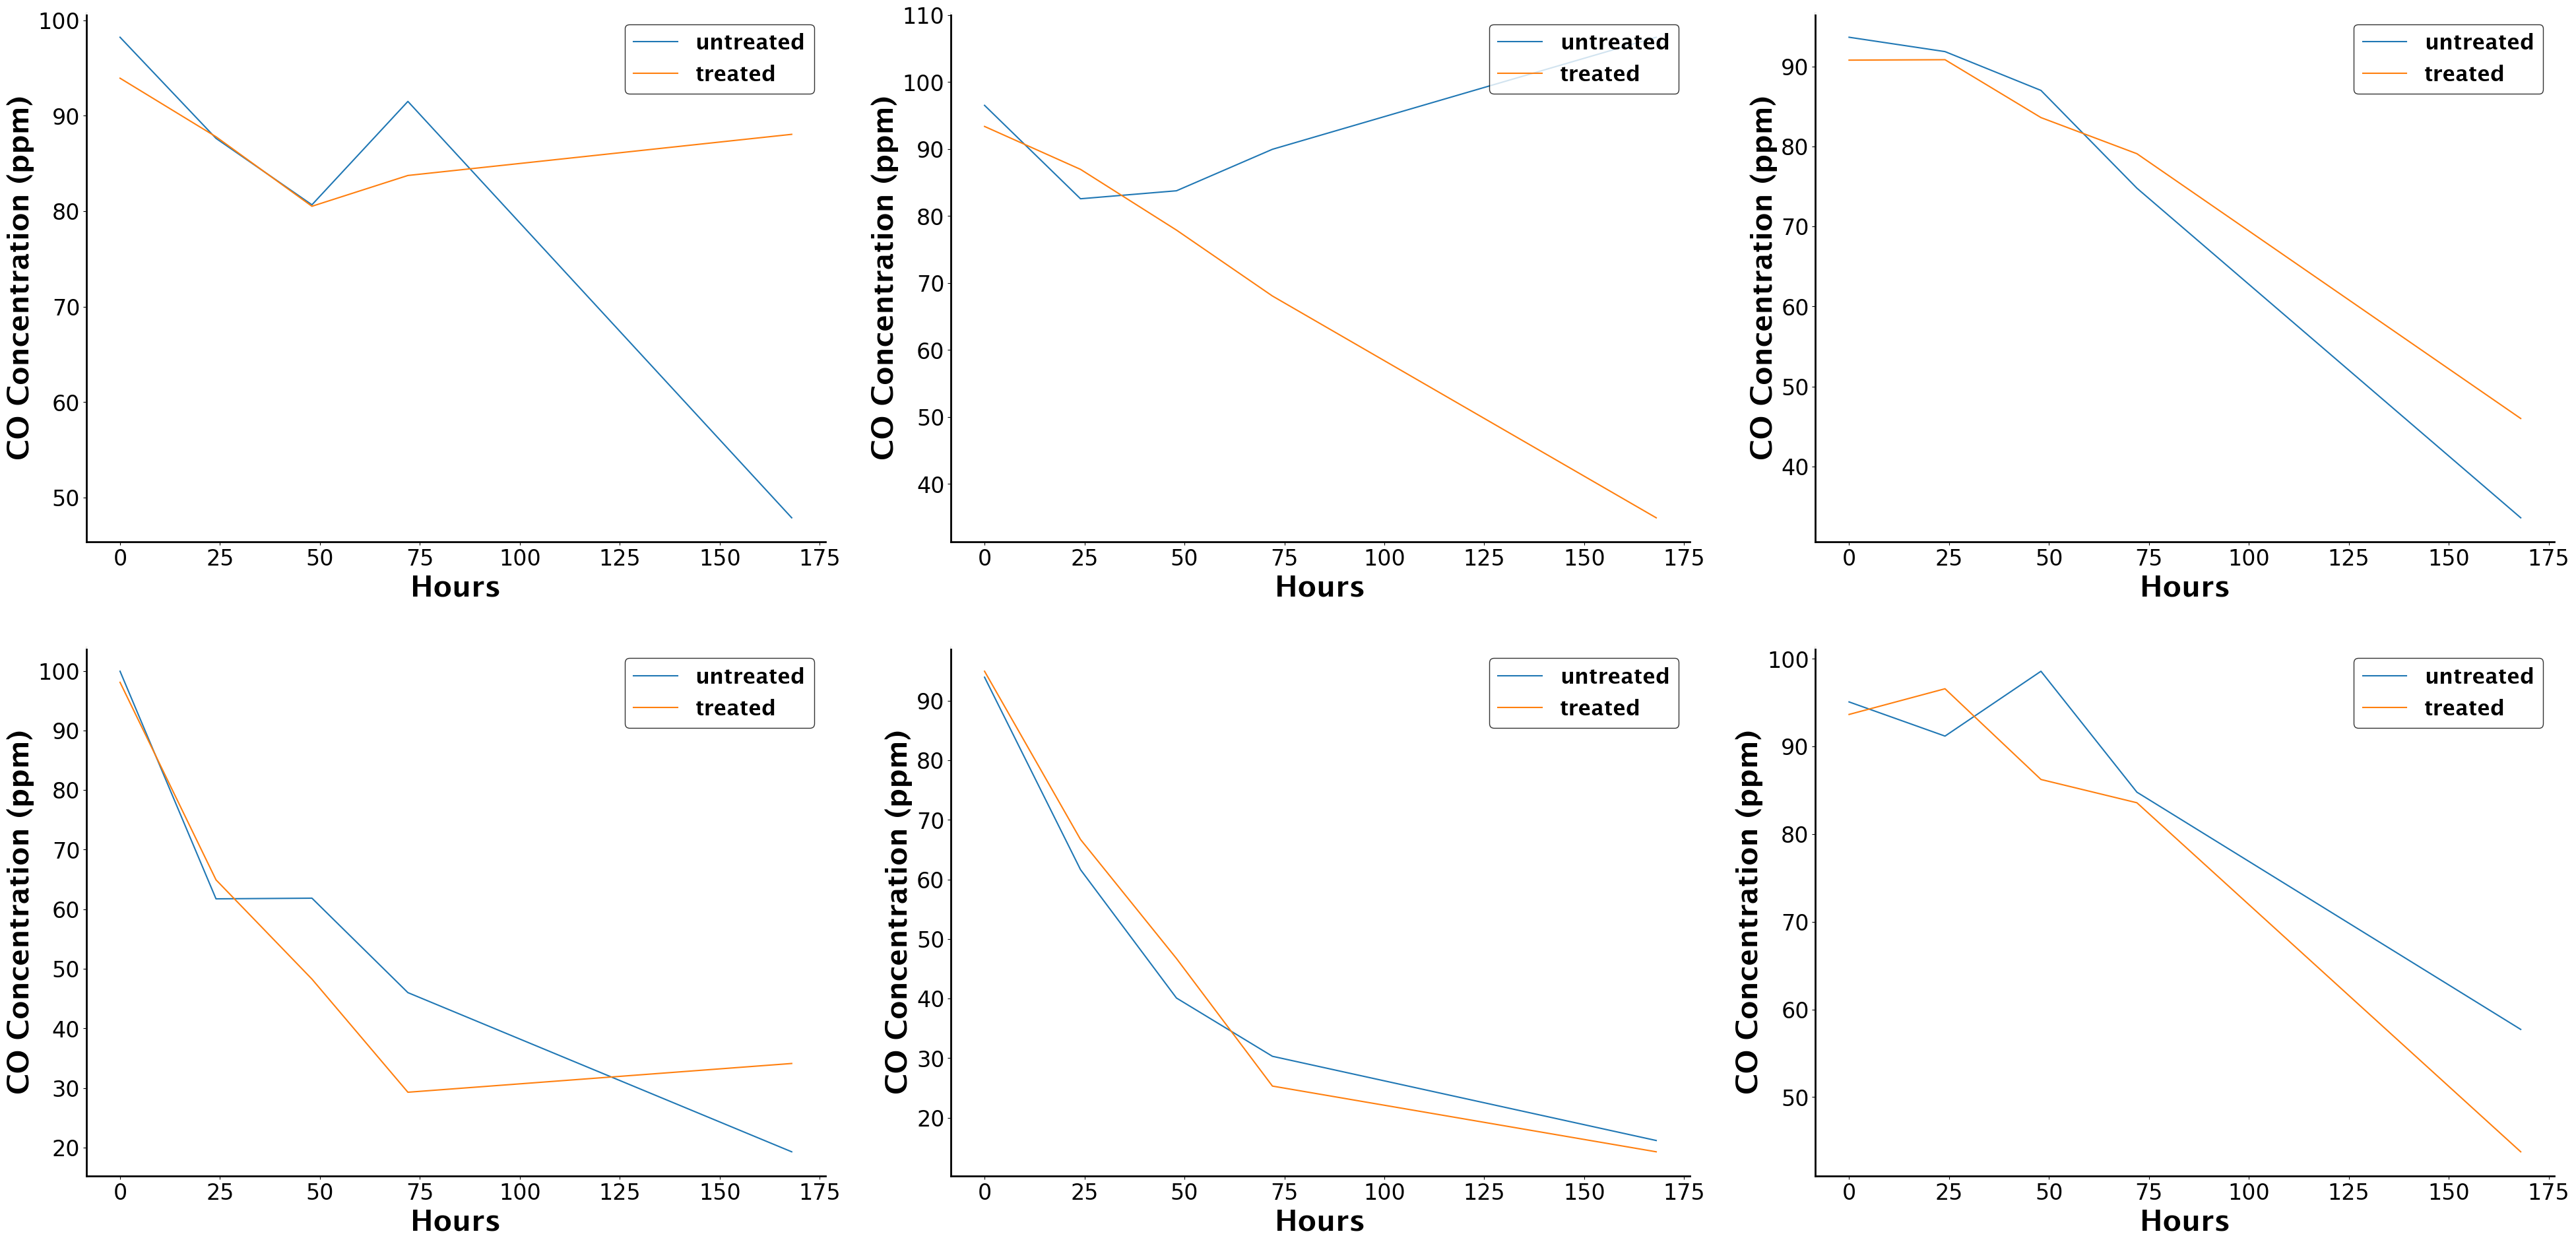

In [61]:
x_col = 'Hours'

pairs = [('TEQ-H', 'TEQ-C'), ('IR64-H', 'IR64-C'), ('J85-H', 'J85-C'), ('Cyp-H', 'Cyp-C'), ('LG-H', 'LG-C'), ('Ben-H', 'Ben-C')]

# Fix: Use plt.subplots() instead of plt.subplot()
fig, axs = plt.subplots(2, 3, figsize=(40, 20))  # Increased figure size for more space

# Set the figure background to black
fig.patch.set_facecolor('white')

# Add significantly more space between subplots and from edges
# Increased wspace and hspace values for more horizontal and vertical spacing
plt.subplots_adjust(left=0.5, right=0.88, bottom=0.5, top=2, wspace=0.5, hspace=0.6)

for ax, (y1, y2) in zip(axs.flatten(), pairs):
    # Set each subplot background to black
    ax.set_facecolor('white')
    
    ax.plot(conc[x_col], conc[y1], label= 'untreated')
    ax.plot(conc[x_col], conc[y2], label= 'treated')
    
    # Set font color to white for all text elements with Times New Roman font
    # Make x and y labels bold with font size 20
    ax.set_xlabel(x_col, color='black', fontfamily='Lucida Sans', fontweight='bold', fontsize=32)
    ax.set_ylabel('CO Concentration (ppm)', color='black', fontfamily='Lucida Sans', fontweight='bold', fontsize=32)
    
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Fixed indentation here - this line needed to be indented
    
    # Set axes line color to white
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('white')
    
    # Set tick colors to white and increase tick label size
    ax.tick_params(axis='x', colors='black', labelsize=24)
    ax.tick_params(axis='y', colors='black', labelsize=24)
    ax.title.set_color('black')
    
    # Position legend at lower right with white text in Times New Roman
    # Removed fontweight parameter from legend() call
    legend = ax.legend(loc='upper right', fontsize=24)
    
    # Set font properties for legend text after creating the legend
    plt.setp(legend.get_texts(), color='black', fontfamily='Lucida Sans', fontweight='bold')
    
    # Set legend background to black
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')

plt.tight_layout(pad=5.0)
plt.show()

In [593]:
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests
import pandas as pd

def compute_rate(df, timepoints=None, column=None):
    if timepoints is not None:
        df = df.loc[timepoints]
    if column is None:
        column = df.columns

    slopes = []
    p_values = []

    x = df.index.values.astype(float)
    
    for col in column:
        y = df[col].values.astype(float)
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        slopes.append(round(slope, 2))
        p_values.append(p_value)
    
    # Bonferroni correction applied by default
    _, p_corrected, _, _ = multipletests(p_values, method='bonferroni')
    p_values = [round(p, 3) for p in p_corrected]
    
    return pd.DataFrame({'slope': slopes, 'p_value': p_values}, index=column)

In [595]:
conc.set_index('Hours', inplace = True)

In [597]:
conc

,TEQ-H,TEQ-C,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C
Hours,,,,,,,,,,,,
0,98.229285,93.938706,96.513053,93.366629,93.652667,90.792281,99.945516,98.086266,93.938706,94.939841,95.082860,93.652667
24,87.637837,87.806659,82.573190,86.962551,91.858377,90.845448,61.740604,64.931332,61.639311,66.703959,91.183091,96.585382
48,80.678589,80.524253,83.765311,77.900539,87.006369,83.610975,61.849584,48.268006,40.088192,46.724645,98.581578,86.234689
72,91.507730,83.750171,89.956218,68.062662,74.785880,79.095636,45.996716,29.274867,30.309208,25.309892,84.784512,83.577781
168,47.893009,88.059926,106.678068,34.963743,33.584622,45.996716,19.276235,34.101792,16.173211,14.276919,57.719250,43.755644


In [599]:
indicah = [0, 24, 48, 72, 168]
indicac = ['TEQ-H', 'TEQ-C' ]
indica_rates = compute_rate(conc, timepoints = indicah, column=indicac)
print(indica_rates)

       slope  p_value
TEQ-H  -0.28    0.048
TEQ-C  -0.02    1.000


In [601]:
irh = [0, 24, 48, 72, 168]
irc = ['IR64-H', 'IR64-C' ]
ir_rates = compute_rate(conc, timepoints = irh, column=irc)
print(ir_rates)

        slope  p_value
IR64-H   0.10    0.433
IR64-C  -0.35    0.000


In [603]:
japonicah = [0, 24, 48, 72, 168]
japonicac = ['J85-H', 'J85-C', 'Cyp-H', 'Cyp-C', 'LG-H', 'LG-C']
japonica_rates = compute_rate(conc, timepoints = japonicah, column=japonicac)
japonica_rates

,slope,p_value
J85-H,-0.38,0.015
J85-C,-0.28,0.017
Cyp-H,-0.42,0.149
Cyp-C,-0.32,0.857
LG-H,-0.40,0.351
LG-C,-0.44,0.287


In [605]:
benh = [48, 72, 168]
benc = ['Ben-H', 'Ben-C' ]
ben_rates = compute_rate(conc, timepoints = benh, column=benc)
print(ben_rates)

       slope  p_value
Ben-H  -0.32    0.189
Ben-C  -0.37    0.171


In [607]:
com_col = indica_rates.columns.intersection(japonica_rates.columns)
rates = pd.concat([indica_rates[com_col], ir_rates[com_col], japonica_rates[com_col], ben_rates[com_col]], axis = 0)
rates

,slope,p_value
TEQ-H,-0.28,0.048
TEQ-C,-0.02,1.000
IR64-H,0.10,0.433
IR64-C,-0.35,0.000
J85-H,-0.38,0.015
J85-C,-0.28,0.017
Cyp-H,-0.42,0.149
Cyp-C,-0.32,0.857
LG-H,-0.40,0.351
LG-C,-0.44,0.287


In [609]:
rates.to_csv("CO_dec_rate.csv")

In [611]:
untreated_data = {
    'TEQ': [-0.28],
    'IR64': [0.10],
    'J85': [-0.38],
    'Cyp': [-0.42],
    'LG': [-0.40],
    'Ben': [-0.32]
}

treated_data = {
    'TEQ': [-0.02],
    'IR64': [-0.35],
    'J85': [-0.28],
    'Cyp': [-0.32],
    'LG': [-0.44],
    'Ben': [-0.37]
}

treated = pd.DataFrame(treated_data)
treated

,TEQ,IR64,J85,Cyp,LG,Ben
0,-0.02,-0.35,-0.28,-0.32,-0.44,-0.37


In [613]:
untreated = pd.DataFrame(untreated_data)
untreated

,TEQ,IR64,J85,Cyp,LG,Ben
0,-0.28,0.1,-0.38,-0.42,-0.4,-0.32


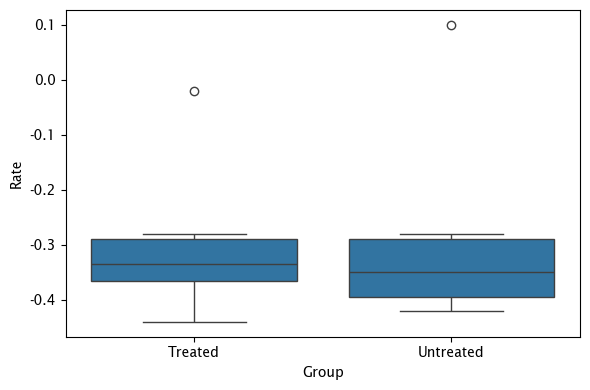

In [615]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'
plt.rcParams['axes.unicode_minus'] = False

data = pd.DataFrame({
    'Rate': treated.iloc[0].tolist() + untreated.iloc[0].tolist(),
    'Group': ['Treated'] * treated.shape[1] + ['Untreated'] * untreated.shape[1]
})

plt.figure(figsize=(6, 4))
sns.boxplot(x='Group', y='Rate', data = data)
plt.tight_layout()
plt.show()

In [616]:
indicat = treated[['TEQ', 'IR64', 'J85']]
indicau = untreated[['TEQ', 'IR64', 'J85']]
japonicat = treated[['Cyp', 'LG', 'Ben']]
japonicau = untreated[['Cyp', 'LG', 'Ben']]

In [619]:
indicat

,TEQ,IR64,J85
0,-0.02,-0.35,-0.28


In [621]:
import pandas as pd
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests

def overall_pvalue(untreated_df, treated_df, paired=True, bonferroni=True):
    # Flatten all values across columns
    untreated_all = untreated_df.values.flatten()
    treated_all = treated_df.values.flatten()
    
    # Choose paired or unpaired test
    if paired and untreated_all.shape[0] == treated_all.shape[0]:
        t_stat, p_val = ttest_rel(untreated_all, treated_all)
    else:
        t_stat, p_val = ttest_ind(untreated_all, treated_all, equal_var=False)
    
    # Bonferroni correction
    if bonferroni:
        p_val_corrected = multipletests([p_val], method='fdr_bh')[1][0]
    else:
        p_val_corrected = p_val
    
    return round(p_val_corrected, 4)

In [623]:
# Usage
overall_p = overall_pvalue(indicat, indicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.9018


In [625]:
# Usage
overall_p = overall_pvalue(japonicat, japonicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.9514


In [627]:
# Usage
overall_p = overall_pvalue(indicat, japonicat, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.1496


In [629]:
# Usage
overall_p = overall_pvalue(japonicau, indicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.3593


In [631]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

def overall_anova_bonf(*dfs, df_names=None):
    """
    Perform overall ANOVA across multiple dataframes and apply Bonferroni correction.
    
    Parameters:
    - dfs: list of dataframes (same shape and column names)
    - df_names: optional list of names for each dataframe
    
    Returns:
    - anova table with Bonferroni-corrected p-values
    """
    
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    
    # Combine all dataframes
    df_list = []
    for df, name in zip(dfs, df_names):
        temp = pd.DataFrame(df)  # copy
        temp['Group'] = name
        df_list.append(temp)
    
    combined = pd.concat(df_list, ignore_index=True)
    
    # Melt for long-format ANOVA
    long_df = combined.melt(id_vars='Group', var_name='Variable', value_name='Value')
    
    # Fit ANOVA model: Value ~ Group
    model = ols('Value ~ Group', data=long_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # Bonferroni correction
    mask = anova_table['PR(>F)'].notna()
    _, corrected_p, _, _ = multipletests(anova_table.loc[mask, 'PR(>F)'], method='bonferroni')
    anova_table['PR(>F) Bonf'] = None
    anova_table.loc[mask, 'PR(>F) Bonf'] = corrected_p
    
    return anova_table

# Example usage
anova_res = overall_anova_bonf(indicat, indicau, japonicat, japonicau, df_names=['Indicat', 'Indicau', 'Japonicat', 'Japonicau'])
print(anova_res)


          sum_sq   df         F    PR(>F) PR(>F) Bonf
Group     0.0950  3.0  1.256614  0.352369    0.352369
Residual  0.2016  8.0       NaN       NaN        None


In [633]:
sample_cols = ['TEQ-H', 'TEQ-C', 'IR64-H', 'IR64-C', 'J85-H', 'J85-C', 'Cyp-H', 'Cyp-C', 'LG-H', 'LG-C', 'Ben-H', 'Ben-C']

conc = lf[sample_cols].subtract(lf['intercept'], axis = 0).divide(lf['slope'], axis = 0)
conc['Hours'] = lf['Hours']
conc

,TEQ-H,TEQ-C,IR64-H,IR64-C,J85-H,J85-C,Cyp-H,Cyp-C,LG-H,LG-C,Ben-H,Ben-C,Hours
0,98.229285,93.938706,96.513053,93.366629,93.652667,90.792281,99.945516,98.086266,93.938706,94.939841,95.082860,93.652667,0
1,87.637837,87.806659,82.573190,86.962551,91.858377,90.845448,61.740604,64.931332,61.639311,66.703959,91.183091,96.585382,24
2,80.678589,80.524253,83.765311,77.900539,87.006369,83.610975,61.849584,48.268006,40.088192,46.724645,98.581578,86.234689,48
3,91.507730,83.750171,89.956218,68.062662,74.785880,79.095636,45.996716,29.274867,30.309208,25.309892,84.784512,83.577781,72
4,47.893009,88.059926,106.678068,34.963743,33.584622,45.996716,19.276235,34.101792,16.173211,14.276919,57.719250,43.755644,168


C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_8032\3202129861.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


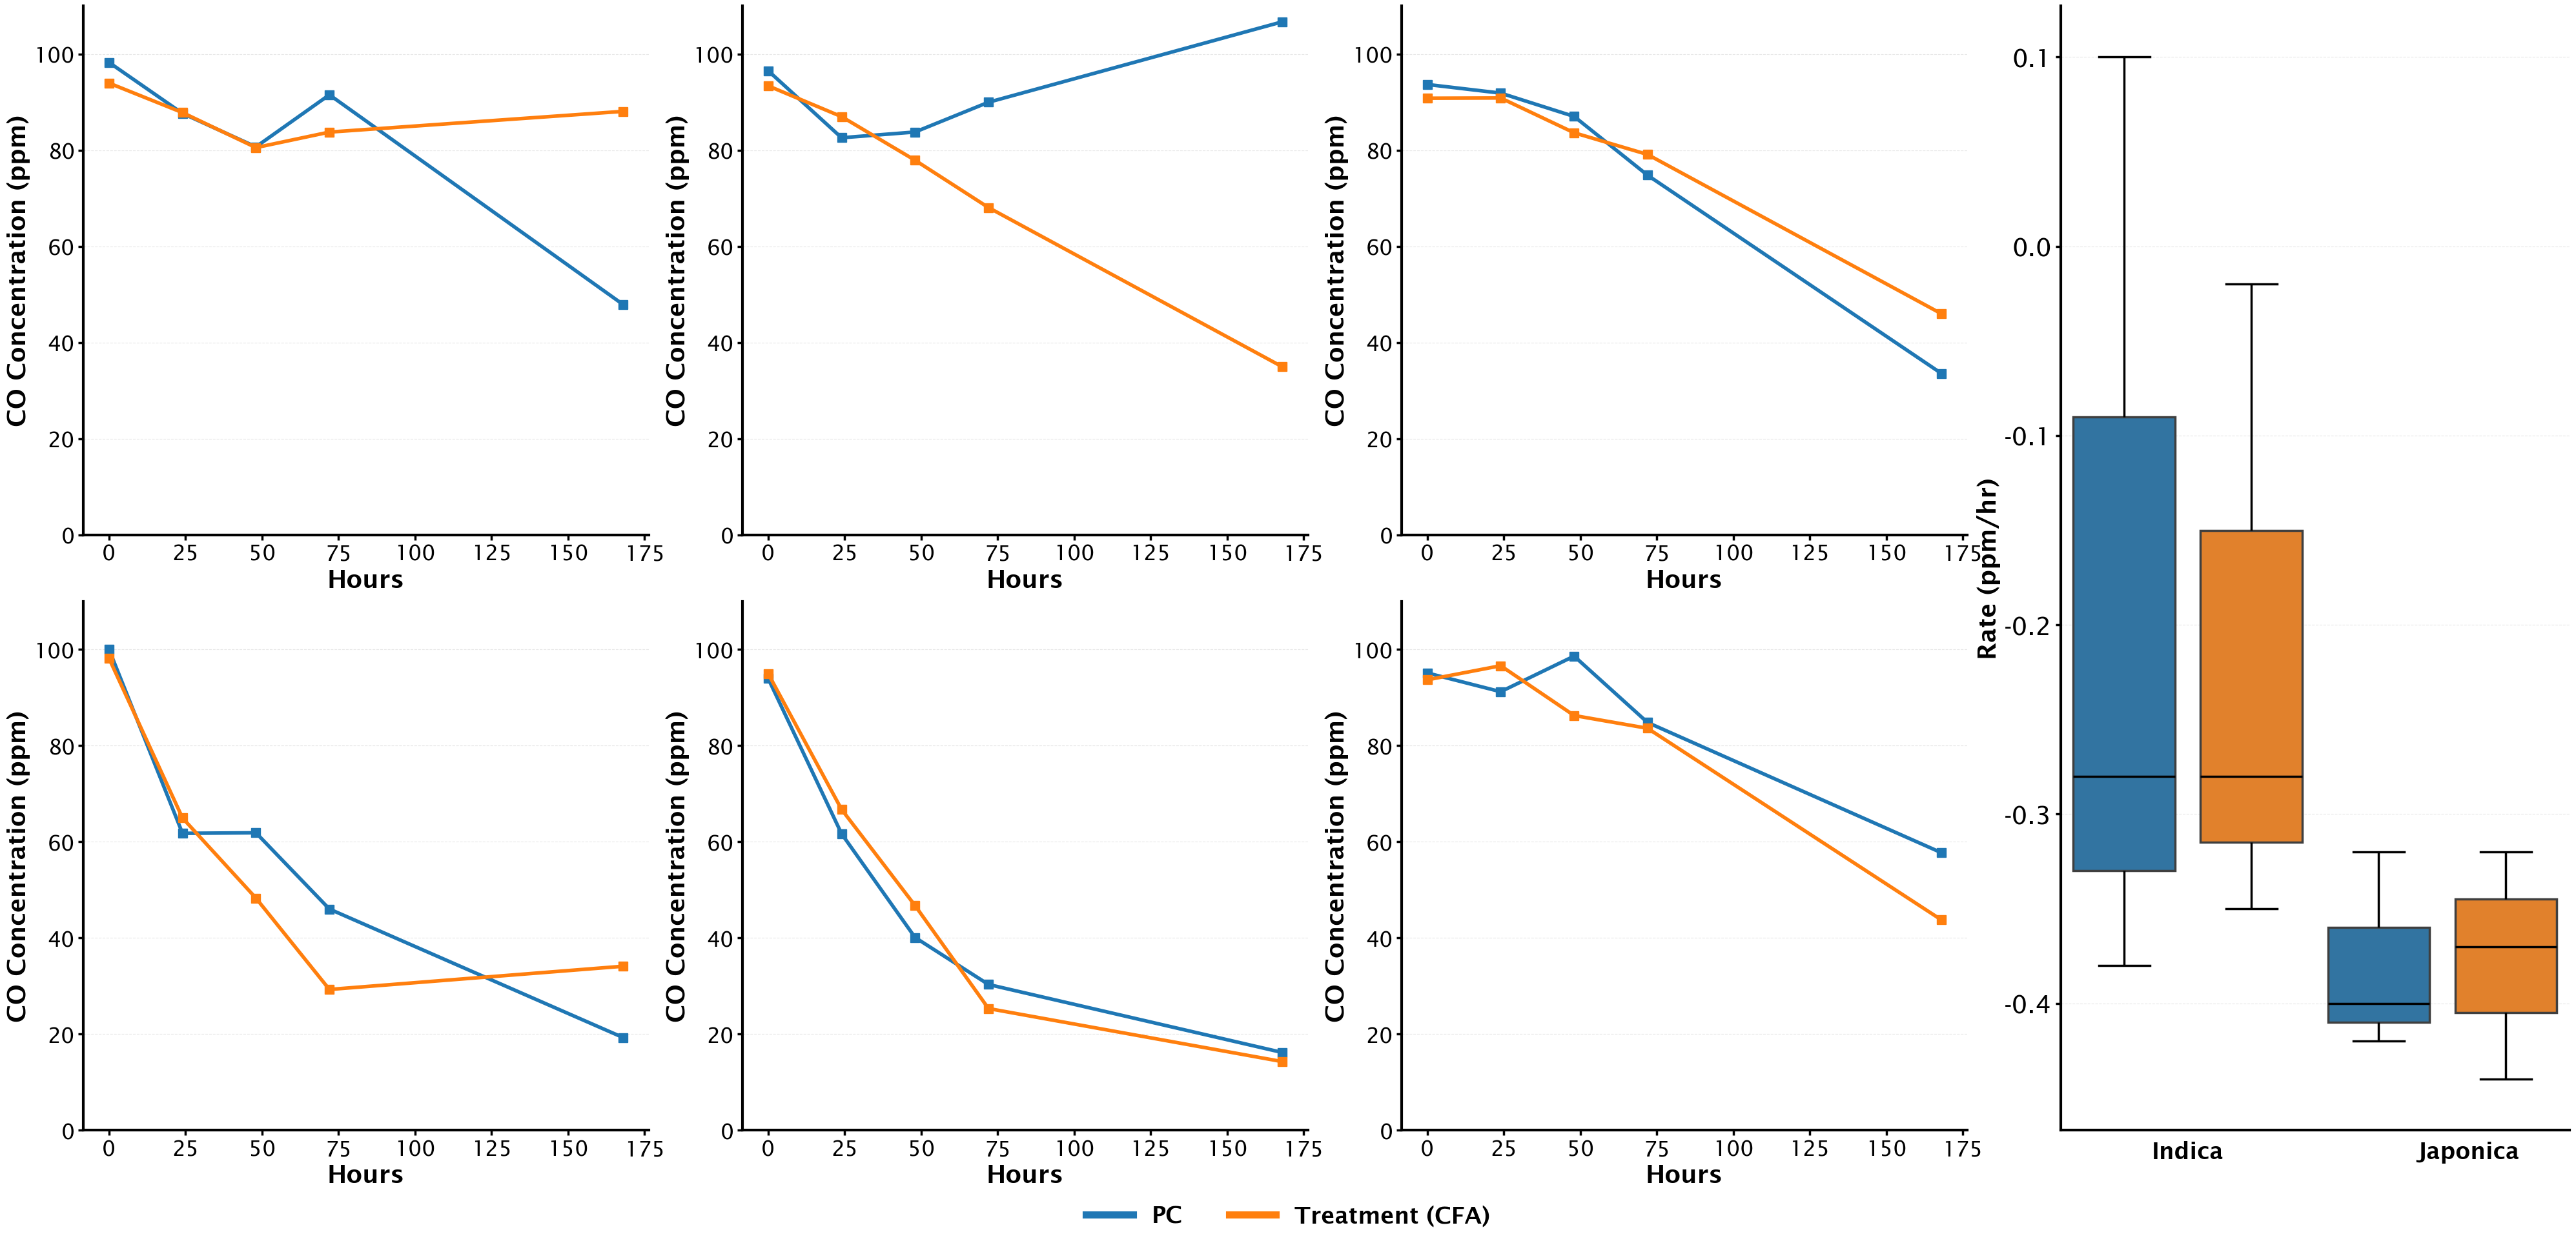

In [635]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# Colors for untreated and treated groups
untreated_color = '#1f77b4'  # Blue
treated_color = '#ff7f0e'    # Orange

# Your x column and pairs for line plots
x_col = 'Hours'
pairs = [('TEQ-H', 'TEQ-C'), ('IR64-H', 'IR64-C'), ('J85-H', 'J85-C'), 
         ('Cyp-H', 'Cyp-C'), ('LG-H', 'LG-C'), ('Ben-H', 'Ben-C')]

# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'
plt.rcParams['axes.unicode_minus'] = False

# Create figure and grid layout (2 rows x 4 cols with last col wide for boxplot)
fig = plt.figure(figsize=(40, 20))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.9])

# --- Line plots (6 plots in 2x3 grid) ---
axs = []
for i in range(6):
    row = i // 3
    col = i % 3
    ax = fig.add_subplot(gs[row, col])
    axs.append(ax)

for ax, (y1, y2) in zip(axs, pairs):
    ax.plot(conc[x_col], conc[y1], label='PC', color=untreated_color, linewidth=4, marker='s', markersize=10)
    ax.plot(conc[x_col], conc[y2], label='Treatment (CFA)', color=treated_color, linewidth=4, marker='s', markersize=10)
    
    ax.set_ylim(0, 110)  # <-- Set y-axis limits here

    ax.set_xlabel(x_col, fontsize=28, fontweight='bold', color='black')
    ax.set_ylabel('CO Concentration (ppm)', fontsize=28, fontweight='bold', color='black')
    
    # Ticks thick and big
    ax.tick_params(axis='x', direction='out', length=6, width=2.5, labelsize=24, colors='black')
    ax.tick_params(axis='y', direction='out', length=6, width=2.5, labelsize=24, colors='black')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Remove top/right spines, thicken bottom/left
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(3)

# --- Boxplot (tall panel on right) ---
ax_box = fig.add_subplot(gs[:, 3])

# Prepare boxplot data
data = pd.DataFrame({
    'Rate': indicat.iloc[0].tolist() + indicau.iloc[0].tolist() + 
            japonicat.iloc[0].tolist() + japonicau.iloc[0].tolist(),
    'Group': ['Indica Treated'] * indicat.shape[1] +
             ['Indica Untreated'] * indicau.shape[1] +
             ['Japonica Treated'] * japonicat.shape[1] +
             ['Japonica Untreated'] * japonicau.shape[1]
})

# Order of groups in boxplot
custom_order = ['Indica Untreated', 'Indica Treated', 'Japonica Untreated', 'Japonica Treated']
custom_labels = ['', '', '', '']  # short labels for boxplot x-ticks

sns.boxplot(
    x='Group', y='Rate', data=data, ax=ax_box,
    order=custom_order,
    linewidth=2.5,
    palette={
        'Indica Untreated': untreated_color,
        'Japonica Untreated': untreated_color,
        'Indica Treated': treated_color,
        'Japonica Treated': treated_color
    }
)

# Set custom x-tick labels
ax_box.set_xticks(range(len(custom_labels)))
ax_box.set_xticklabels(custom_labels, fontsize=22, fontweight='bold', color='black')

# Add "Indica" and "Japonica" group labels below x-axis, centered
ax_box.text(0.25, -0.025, 'Indica', transform=ax_box.transAxes,
            ha='center', fontsize=26, fontweight='bold', color='black')
ax_box.text(0.80, -0.025, 'Japonica', transform=ax_box.transAxes,
            ha='center', fontsize=26, fontweight='bold', color='black')

ax_box.set_ylabel('Rate (ppm/hr)', fontsize=28, fontweight='bold', color='black')
ax_box.set_xlabel('', fontsize=28, fontweight='bold')

# Thicken ticks and axis lines on boxplot
ax_box.tick_params(axis='x', direction='out', length=6, width=2.5, labelsize=24, colors='white')
ax_box.tick_params(axis='y', direction='out', length=6, width=2.5, labelsize=28, colors='black')
ax_box.grid(True, axis='y', linestyle='--', alpha=0.3)

for spine in ['top', 'right']:
    ax_box.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax_box.spines[spine].set_visible(True)
    ax_box.spines[spine].set_color('black')
    ax_box.spines[spine].set_linewidth(3)

# Thicken box edges and whiskers
for artist in ax_box.artists:
    artist.set_edgecolor('black')
    artist.set_linewidth(3)
for line in ax_box.lines:
    line.set_linewidth(2.5)
    line.set_color('black')

# --- Shared Legend ---
custom_lines = [
    Line2D([0], [0], color=untreated_color, lw=8),
    Line2D([0], [0], color=treated_color, lw=8)
]

legend = fig.legend(
    custom_lines, ['PC', 'Treatment (CFA)'],
    loc='lower center', fontsize=26, frameon=False, ncol=2,
    bbox_to_anchor=(0.5, 0.03)
)
plt.setp(legend.get_texts(), fontweight='bold')

# --- Layout and show/save ---
plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave room at bottom for legend
plt.savefig('GC-MS.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [636]:
treated = treated.drop(columns = ['IR64'])
treated

,TEQ,J85,Cyp,LG,Ben
0,-0.02,-0.28,-0.32,-0.44,-0.37


In [637]:
untreated = untreated.drop(columns = ['IR64'])
untreated

,TEQ,J85,Cyp,LG,Ben
0,-0.28,-0.38,-0.42,-0.4,-0.32


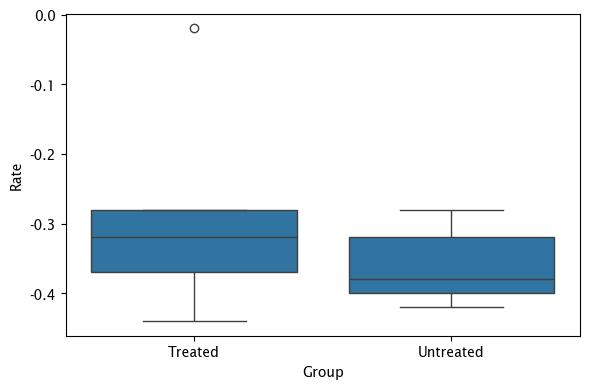

In [638]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'
plt.rcParams['axes.unicode_minus'] = False

data = pd.DataFrame({
    'Rate': treated.iloc[0].tolist() + untreated.iloc[0].tolist(),
    'Group': ['Treated'] * treated.shape[1] + ['Untreated'] * untreated.shape[1]
})

plt.figure(figsize=(6, 4))
sns.boxplot(x='Group', y='Rate', data = data)
plt.tight_layout()
plt.show()

In [639]:
indicat = treated[['TEQ', 'J85']]
indicau = untreated[['TEQ', 'J85']]
japonicat = treated[['Cyp', 'LG', 'Ben']]
japonicau = untreated[['Cyp', 'LG', 'Ben']]

C:\Users\dkb1g24\AppData\Local\Temp\ipykernel_8032\867346477.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


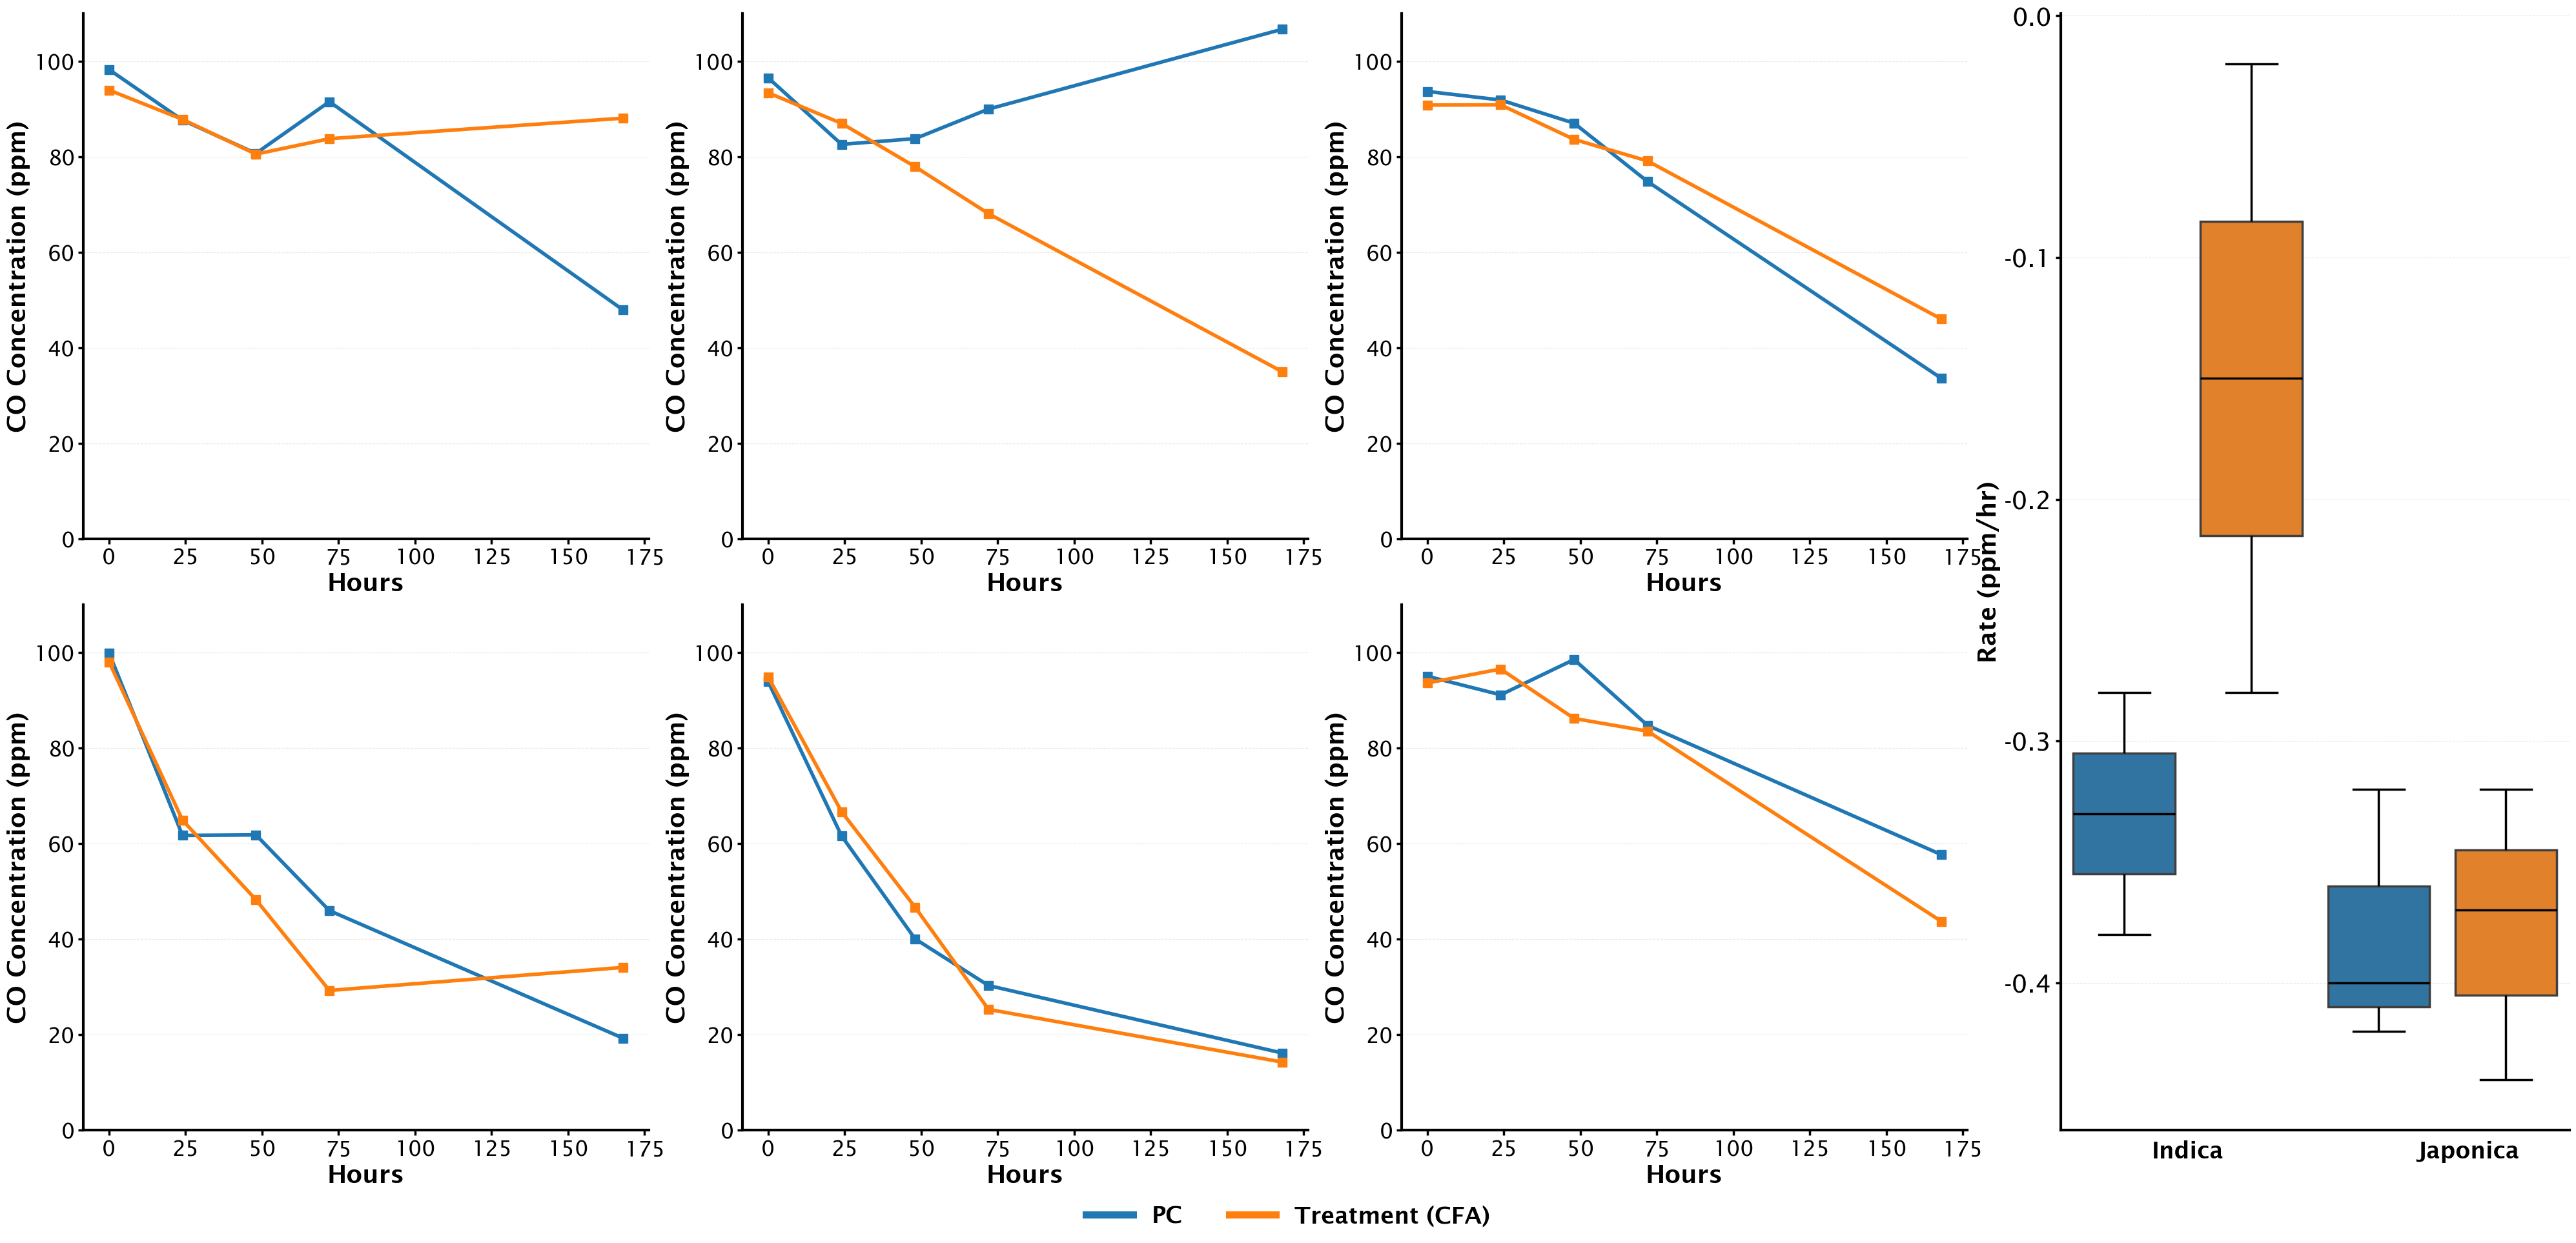

In [640]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# Colors for untreated and treated groups
untreated_color = '#1f77b4'  # Blue
treated_color = '#ff7f0e'    # Orange

# Your x column and pairs for line plots
x_col = 'Hours'
pairs = [('TEQ-H', 'TEQ-C'), ('IR64-H', 'IR64-C'), ('J85-H', 'J85-C'), 
         ('Cyp-H', 'Cyp-C'), ('LG-H', 'LG-C'), ('Ben-H', 'Ben-C')]

# Set the font globally to Lucida Sans
plt.rcParams['font.family'] = 'Lucida Sans'
plt.rcParams['axes.unicode_minus'] = False

# Create figure and grid layout (2 rows x 4 cols with last col wide for boxplot)
fig = plt.figure(figsize=(40, 20))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.9])

# --- Line plots (6 plots in 2x3 grid) ---
axs = []
for i in range(6):
    row = i // 3
    col = i % 3
    ax = fig.add_subplot(gs[row, col])
    axs.append(ax)

for ax, (y1, y2) in zip(axs, pairs):
    ax.plot(conc[x_col], conc[y1], label='PC', color=untreated_color, linewidth=4, marker='s', markersize=10)
    ax.plot(conc[x_col], conc[y2], label='Treatment (CFA)', color=treated_color, linewidth=4, marker='s', markersize=10)
    
    ax.set_ylim(0, 110)  # <-- Set y-axis limits here

    ax.set_xlabel(x_col, fontsize=28, fontweight='bold', color='black')
    ax.set_ylabel('CO Concentration (ppm)', fontsize=28, fontweight='bold', color='black')
    
    # Ticks thick and big
    ax.tick_params(axis='x', direction='out', length=6, width=2.5, labelsize=24, colors='black')
    ax.tick_params(axis='y', direction='out', length=6, width=2.5, labelsize=24, colors='black')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Remove top/right spines, thicken bottom/left
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(3)

# --- Boxplot (tall panel on right) ---
ax_box = fig.add_subplot(gs[:, 3])

# Prepare boxplot data
data = pd.DataFrame({
    'Rate': indicat.iloc[0].tolist() + indicau.iloc[0].tolist() + 
            japonicat.iloc[0].tolist() + japonicau.iloc[0].tolist(),
    'Group': ['Indica Treated'] * indicat.shape[1] +
             ['Indica Untreated'] * indicau.shape[1] +
             ['Japonica Treated'] * japonicat.shape[1] +
             ['Japonica Untreated'] * japonicau.shape[1]
})

# Order of groups in boxplot
custom_order = ['Indica Untreated', 'Indica Treated', 'Japonica Untreated', 'Japonica Treated']
custom_labels = ['', '', '', '']  # short labels for boxplot x-ticks

sns.boxplot(
    x='Group', y='Rate', data=data, ax=ax_box,
    order=custom_order,
    linewidth=2.5,
    palette={
        'Indica Untreated': untreated_color,
        'Japonica Untreated': untreated_color,
        'Indica Treated': treated_color,
        'Japonica Treated': treated_color
    }
)

# Set custom x-tick labels
ax_box.set_xticks(range(len(custom_labels)))
ax_box.set_xticklabels(custom_labels, fontsize=22, fontweight='bold', color='black')

# Add "Indica" and "Japonica" group labels below x-axis, centered
ax_box.text(0.25, -0.025, 'Indica', transform=ax_box.transAxes,
            ha='center', fontsize=26, fontweight='bold', color='black')
ax_box.text(0.80, -0.025, 'Japonica', transform=ax_box.transAxes,
            ha='center', fontsize=26, fontweight='bold', color='black')

ax_box.set_ylabel('Rate (ppm/hr)', fontsize=28, fontweight='bold', color='black')
ax_box.set_xlabel('', fontsize=28, fontweight='bold')

# Thicken ticks and axis lines on boxplot
ax_box.tick_params(axis='x', direction='out', length=6, width=2.5, labelsize=24, colors='white')
ax_box.tick_params(axis='y', direction='out', length=6, width=2.5, labelsize=28, colors='black')
ax_box.grid(True, axis='y', linestyle='--', alpha=0.3)

for spine in ['top', 'right']:
    ax_box.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax_box.spines[spine].set_visible(True)
    ax_box.spines[spine].set_color('black')
    ax_box.spines[spine].set_linewidth(3)

# Thicken box edges and whiskers
for artist in ax_box.artists:
    artist.set_edgecolor('black')
    artist.set_linewidth(3)
for line in ax_box.lines:
    line.set_linewidth(2.5)
    line.set_color('black')

# --- Shared Legend ---
custom_lines = [
    Line2D([0], [0], color=untreated_color, lw=8),
    Line2D([0], [0], color=treated_color, lw=8)
]

legend = fig.legend(
    custom_lines, ['PC', 'Treatment (CFA)'],
    loc='lower center', fontsize=26, frameon=False, ncol=2,
    bbox_to_anchor=(0.5, 0.03)
)
plt.setp(legend.get_texts(), fontweight='bold')

# --- Layout and show/save ---
plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave room at bottom for legend
plt.savefig('GC-MS1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [641]:
# Usage
overall_p = overall_pvalue(indicat, indicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.2662


In [642]:
# Usage
overall_p = overall_pvalue(japonicat, japonicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.9514


In [643]:
# Usage
overall_p = overall_pvalue(indicat, japonicat, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.3169


In [644]:
# Usage
overall_p = overall_pvalue(japonicau, indicau, paired=True, bonferroni=True)
print("Overall Bonferroni-corrected p-value:", overall_p)

Overall Bonferroni-corrected p-value: 0.4936


In [645]:
anova_res = overall_anova_bonf(indicat, indicau, japonicat, japonicau, df_names=['Indicat', 'Indicau','Japonicat', 'Japonicau'])
print(anova_res)

            sum_sq   df         F    PR(>F) PR(>F) Bonf
Group     0.078343  3.0  3.032645  0.114861    0.114861
Residual  0.051667  6.0       NaN       NaN        None
